# Control Systems Fundamentals: From Models to Feedback Design

This notebook builds control-system intuition from physical models to practical feedback design. It combines derivations, executable examples, and plots using **NumPy**, **SciPy**, **Matplotlib**, **SymPy**, and **python-control**.

## Learning objectives

By the end, you should be able to:

- derive transfer functions from differential equations;
- interpret natural frequency $\omega_n$ and damping ratio $\zeta$;
- predict stability, speed, and oscillation from poles and zeros;
- connect second-order dynamics to a physical series RLC circuit;
- evaluate transient response, steady-state error, and frequency-domain robustness;
- explain root locus, PID control, state space, controllability, observability, and sampled-data stability;
- follow a repeatable analysis and controller-design workflow.

> **Convention:** Continuous-time transfer functions use $s$. Unless stated otherwise, feedback is negative and unity feedback means $H(s)=1$.

## 1. Python Environment and Control Libraries

The first code cell imports the numerical, symbolic, plotting, and control libraries used throughout the notebook and prints their versions. Keeping this cell near the top makes the computational environment explicit and reproducible.

In [27]:
import sys

import control as ct
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sympy as sp
from scipy import signal

np.set_printoptions(precision=4, suppress=True)
mpl.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.28,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 2.0,
    "font.size": 11,
})
COLORS = plt.get_cmap("tab10").colors

print(f"Python       {sys.version.split()[0]}")
print(f"NumPy       {np.__version__}")
print(f"SciPy       {scipy.__version__}")
print(f"SymPy       {sp.__version__}")
print(f"Matplotlib  {mpl.__version__}")
print(f"control     {ct.__version__}")

Python       3.14.6
NumPy       2.5.2
SciPy       1.18.1
SymPy       1.14.0
Matplotlib  3.11.1
control     0.10.2


## 2. Modeling Dynamic Systems

A **dynamic system** stores energy or information, so its present output depends on past behavior. A model usually starts with conservation laws:

- Newton's law: $\sum F=m\ddot{x}$
- Kirchhoff's laws: $\sum v=0$ and $\sum i=0$
- conservation of mass, charge, momentum, or energy

Most introductory control methods assume a **linear time-invariant (LTI)** model. Linearity gives superposition; time invariance means the governing parameters do not change with time. Real plants are often approximated as LTI near an operating point.

### Mass-spring-damper example

For displacement $x(t)$, external force $F(t)$, mass $m$, viscous damping $b$, and stiffness $k$,

$$m\ddot{x}(t)+b\dot{x}(t)+kx(t)=F(t).$$

With zero initial conditions, the Laplace derivative rule $\mathcal{L}\{\dot{x}\}=sX(s)$ gives

$$(ms^2+bs+k)X(s)=F(s),$$

so the force-to-position transfer function is

$$G(s)=\frac{X(s)}{F(s)}=\frac{1}{ms^2+bs+k}.$$

The model is second order because its highest derivative is second order. The state of this mechanical system can be represented by position and velocity.

Laplace-domain equation:


Eq(X(s)*(b*s + k + m*s**2), F(s))

Force-to-position transfer function G(s) = X(s)/F(s):


1/(b*s + k + m*s**2)

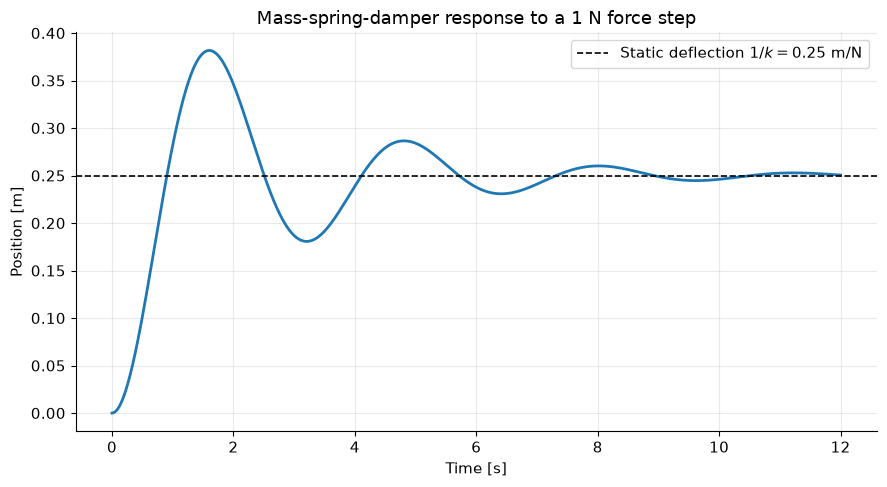

In [2]:
s = sp.symbols("s")
m_sym, b_sym, k_sym = sp.symbols("m b k", positive=True)
X_s, F_s = sp.symbols("X(s) F(s)")

laplace_equation = sp.Eq((m_sym * s**2 + b_sym * s + k_sym) * X_s, F_s)
G_symbolic = sp.simplify(sp.solve(laplace_equation, X_s)[0] / F_s)
print("Laplace-domain equation:")
display(laplace_equation)
print("Force-to-position transfer function G(s) = X(s)/F(s):")
display(G_symbolic)

m_value, b_value, k_value = 1.0, 0.8, 4.0
mass_spring_damper = ct.tf([1.0], [m_value, b_value, k_value])
time = np.linspace(0, 12, 1200)
time_out, position = ct.step_response(mass_spring_damper, T=time)

plt.plot(time_out, position, color=COLORS[0])
plt.axhline(1 / k_value, color="black", linestyle="--", linewidth=1.2,
            label=f"Static deflection $1/k={1/k_value:.2f}$ m/N")
plt.title("Mass-spring-damper response to a 1 N force step")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Transfer Functions and Block Diagrams

For an LTI system with zero initial conditions, the **transfer function** is

$$G(s)=\frac{Y(s)}{U(s)}=\frac{b_ms^m+\cdots+b_0}{a_ns^n+\cdots+a_0}.$$

Key vocabulary:

| Concept | Meaning |
|---|---|
| Order | Degree $n$ of the denominator after cancellations |
| Relative degree | $n-m$ |
| Proper / strictly proper | $n\ge m$ / $n>m$ |
| Poles | Roots of the denominator |
| Zeros | Roots of the numerator |
| DC gain | $G(0)$ when finite |

Ideal block-diagram algebra is simple:

- series: $G_{series}=G_1G_2$
- parallel: $G_{parallel}=G_1+G_2$
- negative feedback: $G_{cl}=G/(1+GH)$

For a forward path $G$ and feedback path $H$,

$$Y=G(R-HY)\quad\Longrightarrow\quad \frac{Y}{R}=\frac{G}{1+GH}.$$

The equation $1+G(s)H(s)=0$ is the **closed-loop characteristic equation**. Its roots are the closed-loop poles and therefore govern closed-loop stability and natural response.

G1(s) = <TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    1
  -----
  s + 1
Series G1 G2 = <TransferFunction>: sys[10]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        2
  -------------
  s^2 + 4 s + 3
Parallel G1 + G2 = <TransferFunction>: sys[11]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     3 s + 5
  -------------
  s^2 + 4 s + 3
Unity-feedback G1 G2 / (1 + G1 G2) = <TransferFunction>: sys[14]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        2
  -------------
  s^2 + 4 s + 5
Closed-loop poles: [-2.+1.j -2.-1.j]


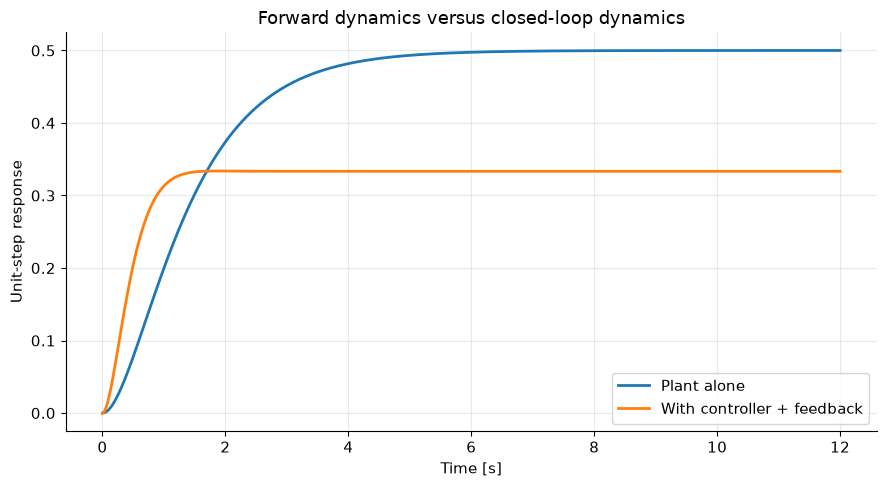

In [3]:
s_tf = ct.tf("s")
G1 = 1 / (s_tf + 1)
G2 = 2 / (s_tf + 3)
series_connection = ct.series(G1, G2)
parallel_connection = ct.parallel(G1, G2)
feedback_connection = ct.feedback(G1 * G2, 1)

print("G1(s) =", G1)
print("Series G1 G2 =", series_connection)
print("Parallel G1 + G2 =", parallel_connection)
print("Unity-feedback G1 G2 / (1 + G1 G2) =", feedback_connection)
print("Closed-loop poles:", ct.poles(feedback_connection))

plant_example = 1 / (s_tf**2 + 3 * s_tf + 2)
controller_example = 5 * (s_tf + 1) / (s_tf + 5)
closed_loop_example = ct.feedback(controller_example * plant_example, 1)
time = np.linspace(0, 12, 1200)

plt.plot(*ct.step_response(plant_example, T=time), label="Plant alone")
plt.plot(*ct.step_response(closed_loop_example, T=time), label="With controller + feedback")
plt.title("Forward dynamics versus closed-loop dynamics")
plt.xlabel("Time [s]")
plt.ylabel("Unit-step response")
plt.legend()
plt.tight_layout()
plt.show()

## 3A. First-Order Systems and Standard Test Signals

Common test inputs reveal different aspects of a model:

- impulse $\delta(t)$: exposes the impulse response $h(t)$;
- step: tests transition, steady value, overshoot, and settling;
- ramp: tests tracking of a steadily changing command;
- sinusoid: tests gain and phase versus frequency.

For a causal LTI system initially at rest, the output is the convolution

$$y(t)=(h*u)(t)=\int_0^t h(t-\tau)u(\tau)\,d\tau,$$

and $G(s)=\mathcal{L}\{h(t)\}$.

The standard first-order model is

$$\tau\dot{y}+y=Ku,
\qquad G(s)=\frac{K}{\tau s+1}.$$

It has one pole at $-1/\tau$. Its unit-step response is

$$y(t)=K\left(1-e^{-t/\tau}\right).$$

At one time constant, $y(\tau)=K(1-e^{-1})\approx0.632K$. Useful approximations are

$$t_{10\%-90\%}\approx2.2\tau,\qquad t_{s,2\%}\approx4\tau.$$

Thus smaller $\tau$ means a pole farther left and a faster response.

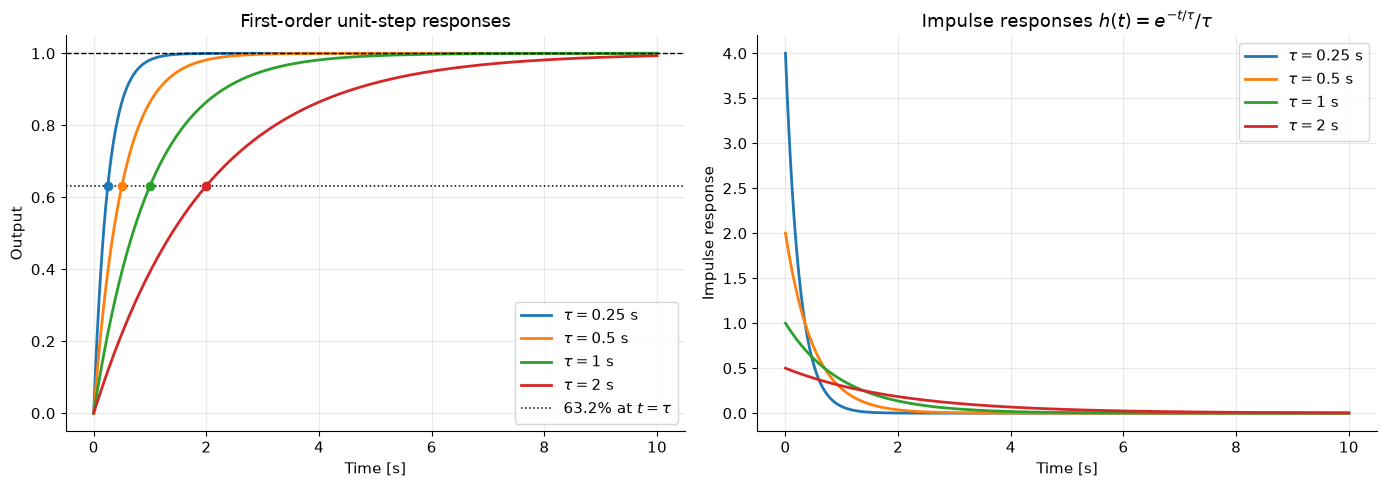

In [25]:
first_order_time = np.linspace(0, 10, 2000)
time_constants = [0.25, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for index, time_constant in enumerate(time_constants):
    first_order_system = ct.tf([1.0], [time_constant, 1.0])
    step_result = ct.step_response(first_order_system, T=first_order_time)
    impulse_result = ct.impulse_response(first_order_system, T=first_order_time)
    axes[0].plot(step_result.time, np.asarray(step_result.outputs).squeeze(),
                 color=COLORS[index], label=fr"$\tau={time_constant:g}$ s")
    axes[0].scatter([time_constant], [1 - np.exp(-1)], color=COLORS[index], s=35, zorder=3)
    axes[1].plot(impulse_result.time, np.asarray(impulse_result.outputs).squeeze(),
                 color=COLORS[index], label=fr"$\tau={time_constant:g}$ s")

axes[0].axhline(1 - np.exp(-1), color="black", linestyle=":", linewidth=1.1,
                label=r"63.2% at $t=\tau$")
axes[0].axhline(1, color="black", linestyle="--", linewidth=1)
axes[0].set_title("First-order unit-step responses")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Output")
axes[0].legend()
axes[1].set_title(r"Impulse responses $h(t)=e^{-t/\tau}/\tau$")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Impulse response")
axes[1].legend()

fig.tight_layout()
plt.show()

## 4. Deriving the Standard Second-Order System

Start from a general second-order differential equation with positive leading coefficient:

$$a_2\ddot{y}+a_1\dot{y}+a_0y=b_0u.$$

After a zero-initial-condition Laplace transform,

$$\frac{Y(s)}{U(s)}=\frac{b_0}{a_2s^2+a_1s+a_0}
=\frac{b_0/a_2}{s^2+(a_1/a_2)s+a_0/a_2}.$$

Compare its denominator with the canonical form

$$s^2+2\zeta\omega_n s+\omega_n^2.$$

Matching coefficients gives

$$\boxed{\omega_n=\sqrt{\frac{a_0}{a_2}}},\qquad
\boxed{\zeta=\frac{a_1}{2\sqrt{a_0a_2}}}.$$

For unity DC gain, the canonical transfer function is

$$G(s)=\frac{\omega_n^2}{s^2+2\zeta\omega_ns+\omega_n^2}.$$

For the mass-spring-damper system, $a_2=m$, $a_1=b$, and $a_0=k$, so

$$\omega_n=\sqrt{\frac{k}{m}},\qquad \zeta=\frac{b}{2\sqrt{km}}.$$

The units cancel in $\zeta$, so damping ratio is dimensionless.

## 5. Damping Ratio and Natural Frequency

Solving the characteristic equation gives

$$s_{1,2}=-\zeta\omega_n\pm\omega_n\sqrt{\zeta^2-1}.$$

For $0<\zeta<1$, write the poles as

$$s_{1,2}=-\zeta\omega_n\pm j\omega_d,
\qquad \omega_d=\omega_n\sqrt{1-\zeta^2}.$$

| Damping ratio | Classification | Expected natural response |
|---:|---|---|
| $\zeta<0$ | Negative damping, unstable | Growing oscillation or exponentials |
| $\zeta=0$ | Undamped, marginal idealization | Sustained oscillation |
| $0<\zeta<1$ | Underdamped | Decaying oscillation and possible overshoot |
| $\zeta=1$ | Critically damped | Fastest nonoscillatory canonical response |
| $\zeta>1$ | Overdamped | Two decaying real modes; larger $\zeta$ can be slower |

$\omega_n$ sets the overall time scale, while $\zeta$ sets the response shape. Both are needed to predict speed.

In [4]:
a2, a1, a0, omega_n_sym, zeta_sym = sp.symbols(
    "a_2 a_1 a_0 omega_n zeta", positive=True
)
coefficient_solution = sp.solve(
    [sp.Eq(2 * zeta_sym * omega_n_sym, a1 / a2),
     sp.Eq(omega_n_sym**2, a0 / a2)],
    [omega_n_sym, zeta_sym],
    dict=True,
)[0]
print("Coefficient matching gives:")
display(coefficient_solution)


def second_order_system(zeta, omega_n=4.0):
    """Canonical unity-DC-gain second-order transfer function."""
    return ct.tf([omega_n**2], [1.0, 2.0 * zeta * omega_n, omega_n**2])


def damping_class(zeta):
    if zeta < 0:
        return "unstable (negative damping)"
    if np.isclose(zeta, 0):
        return "undamped"
    if zeta < 1:
        return "underdamped"
    if np.isclose(zeta, 1):
        return "critically damped"
    return "overdamped"


omega_n_value = 4.0
zeta_values = [-0.1, 0.0, 0.2, 0.5, 0.707, 1.0, 1.5, 2.0]
print(f"\nPoles for omega_n = {omega_n_value:g} rad/s")
print(f"{'zeta':>7}  {'classification':>29}  poles")
for zeta in zeta_values:
    poles = np.roots([1.0, 2 * zeta * omega_n_value, omega_n_value**2])
    print(f"{zeta:7.3f}  {damping_class(zeta):>29}  {np.array2string(poles, precision=3)}")

Coefficient matching gives:


{omega_n: sqrt(a_0)/sqrt(a_2), zeta: a_1/(2*sqrt(a_0)*sqrt(a_2))}


Poles for omega_n = 4 rad/s
   zeta                 classification  poles
 -0.100    unstable (negative damping)  [0.4+3.98j 0.4-3.98j]
  0.000                       undamped  [-0.+4.j  0.-4.j]
  0.200                    underdamped  [-0.8+3.919j -0.8-3.919j]
  0.500                    underdamped  [-2.+3.464j -2.-3.464j]
  0.707                    underdamped  [-2.828+2.829j -2.828-2.829j]
  1.000              critically damped  [-4. -4.]
  1.500                     overdamped  [-10.472  -1.528]
  2.000                     overdamped  [-14.928  -1.072]


## 6. Visualizing Different Damping Ratios

The next experiment holds $\omega_n=4\ \mathrm{rad/s}$ fixed and varies only $\zeta$. This isolates damping-ratio effects:

- small positive $\zeta$: quick initial motion but substantial ringing;
- $\zeta\approx0.7$: common compromise between speed and overshoot;
- $\zeta=1$: no overshoot and no repeated pole oscillation;
- large $\zeta$: no oscillation, but a slow dominant real pole;
- $\zeta\le0$: no asymptotic settling.

The unstable case is placed on a separate axis because its growing amplitude would compress the stable curves.

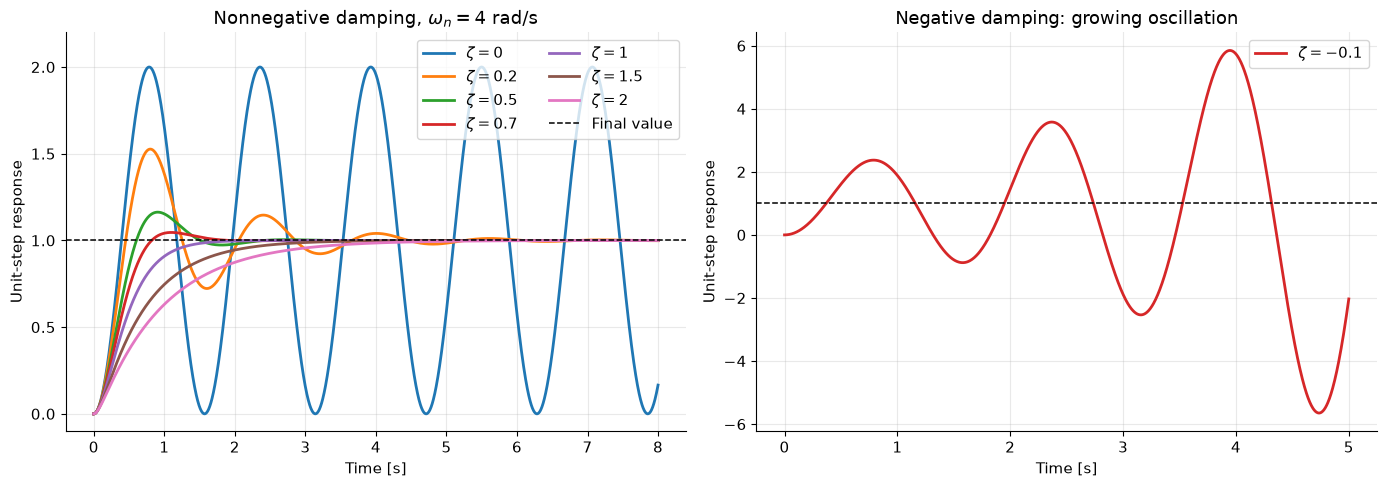

In [5]:
time_stable = np.linspace(0, 8, 2000)
time_unstable = np.linspace(0, 5, 1400)
stable_zetas = [0.0, 0.2, 0.5, 0.7, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for index, zeta in enumerate(stable_zetas):
    response_time, response = ct.step_response(
        second_order_system(zeta, omega_n_value), T=time_stable
    )
    axes[0].plot(response_time, response, color=COLORS[index], label=fr"$\zeta={zeta:g}$")

axes[0].axhline(1, color="black", linestyle="--", linewidth=1.1, label="Final value")
axes[0].set_title(fr"Nonnegative damping, $\omega_n={omega_n_value:g}$ rad/s")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Unit-step response")
axes[0].set_ylim(-0.1, 2.2)
axes[0].legend(ncols=2)

unstable_zeta = -0.1
unstable_time, unstable_response = ct.step_response(
    second_order_system(unstable_zeta, omega_n_value), T=time_unstable
)
axes[1].plot(unstable_time, unstable_response, color=COLORS[3],
             label=fr"$\zeta={unstable_zeta:g}$")
axes[1].axhline(1, color="black", linestyle="--", linewidth=1.1)
axes[1].set_title("Negative damping: growing oscillation")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Unit-step response")
axes[1].legend()

fig.tight_layout()
plt.show()

## 7. Transient-Response Performance Metrics

For the canonical underdamped system with $0<\zeta<1$:

$$\omega_d=\omega_n\sqrt{1-\zeta^2},$$

$$t_p=\frac{\pi}{\omega_d},$$

$$M_p=100\exp\!\left(\frac{-\pi\zeta}{\sqrt{1-\zeta^2}}\right)\%,$$

$$t_s\approx\frac{4}{\zeta\omega_n}\quad\text{for a 2\% band},$$

and the first 0-to-100% crossing is

$$t_r=\frac{\pi-\cos^{-1}(\zeta)}{\omega_d}.$$

Common specifications:

- **rise time:** often 10% to 90%, though conventions vary;
- **peak time:** time of the first maximum;
- **percent overshoot:** peak excursion above the final value;
- **settling time:** first time after which the output remains inside a tolerance band.

These formulas assume a stable, zero-free, canonical second-order system. Additional poles, zeros, delays, saturation, and non-unity final values can make them inaccurate. The code below measures the simulated curve and compares it with the analytical formulas.

In [6]:
def measured_step_metrics(time_values, response_values, final_value=1.0, tolerance=0.02):
    """Measure first 100% crossing, first peak, overshoot, and settling time."""
    crossing_indices = np.flatnonzero(response_values >= final_value)
    rise_time_0_100 = time_values[crossing_indices[0]] if crossing_indices.size else np.nan

    peak_index = int(np.argmax(response_values))
    peak_time = time_values[peak_index]
    overshoot = max(0.0, 100 * (response_values[peak_index] - final_value) / abs(final_value))

    outside = np.flatnonzero(np.abs(response_values - final_value) > tolerance * abs(final_value))
    if outside.size == 0:
        settling_time = 0.0
    elif outside[-1] + 1 < time_values.size:
        settling_time = time_values[outside[-1] + 1]
    else:
        settling_time = np.nan
    return rise_time_0_100, peak_time, overshoot, settling_time


metric_time = np.linspace(0, 15, 20000)
print("Analytical formulas versus measurements from the sampled response")
print(" zeta | tr formula  tr sim | tp formula  tp sim | OS formula  OS sim | Ts approx  Ts sim")
print("-------+--------------------+--------------------+--------------------+-----------------")
for zeta in [0.2, 0.5, 0.7]:
    omega_d = omega_n_value * np.sqrt(1 - zeta**2)
    rise_formula = (np.pi - np.arccos(zeta)) / omega_d
    peak_formula = np.pi / omega_d
    overshoot_formula = 100 * np.exp(-np.pi * zeta / np.sqrt(1 - zeta**2))
    settling_formula = 4 / (zeta * omega_n_value)

    response_time, response = ct.step_response(
        second_order_system(zeta, omega_n_value), T=metric_time
    )
    rise_sim, peak_sim, overshoot_sim, settling_sim = measured_step_metrics(
        response_time, response
    )
    print(
        f" {zeta:5.2f} | {rise_formula:9.3f} {rise_sim:7.3f} |"
        f" {peak_formula:10.3f} {peak_sim:7.3f} |"
        f" {overshoot_formula:10.2f} {overshoot_sim:7.2f} |"
        f" {settling_formula:9.3f} {settling_sim:7.3f}"
    )

Analytical formulas versus measurements from the sampled response
 zeta | tr formula  tr sim | tp formula  tp sim | OS formula  OS sim | Ts approx  Ts sim
-------+--------------------+--------------------+--------------------+-----------------
  0.20 |     0.452   0.452 |      0.802   0.802 |      52.66   52.66 |     5.000   4.901
  0.50 |     0.605   0.605 |      0.907   0.907 |      16.30   16.30 |     2.000   2.019
  0.70 |     0.821   0.822 |      1.100   1.100 |       4.60    4.60 |     1.429   1.495


## 8. Modeling a Series RLC Circuit

Consider a series resistor $R$, inductor $L$, and capacitor $C$, with input voltage $v_{in}$ across the series branch and output $v_C$ across the capacitor.

Kirchhoff's voltage law gives

$$v_{in}=v_R+v_L+v_C=Ri+L\frac{di}{dt}+v_C.$$

Because the series current is the capacitor current,

$$i=C\frac{dv_C}{dt}.$$

Substitution produces

$$LC\frac{d^2v_C}{dt^2}+RC\frac{dv_C}{dt}+v_C=v_{in}.$$

Therefore,

$$H_C(s)=\frac{V_C(s)}{V_{in}(s)}
=\frac{1}{LCs^2+RCs+1}
=\frac{1/(LC)}{s^2+(R/L)s+1/(LC)}.$$

Matching the standard second-order denominator gives

$$\boxed{\omega_n=\frac{1}{\sqrt{LC}}},\qquad
\boxed{\zeta=\frac{R}{2}\sqrt{\frac{C}{L}}}.$$

Useful equivalent relations are

$$\boxed{R_{crit}=2\sqrt{\frac{L}{C}}},\qquad
Q=\frac{1}{2\zeta}=\frac{1}{R}\sqrt{\frac{L}{C}}.$$

The inductor and capacitor exchange magnetic and electric energy. Resistance dissipates that energy, increasing damping. The denominator, and thus the poles, is common to all voltages and currents in this series circuit, but different measured outputs can introduce different zeros.

In [7]:
R_sym, L_sym, C_sym = sp.symbols("R L C", positive=True)
rlc_solution = sp.solve(
    [sp.Eq(2 * zeta_sym * omega_n_sym, R_sym / L_sym),
     sp.Eq(omega_n_sym**2, 1 / (L_sym * C_sym))],
    [omega_n_sym, zeta_sym],
    dict=True,
)[0]
print("RLC coefficient matching gives:")
display(rlc_solution)

L_value = 10e-3       # H
C_value = 100e-6      # F
omega_n_rlc = 1 / np.sqrt(L_value * C_value)
critical_resistance = 2 * np.sqrt(L_value / C_value)
print(f"For L = {L_value * 1e3:g} mH and C = {C_value * 1e6:g} uF:")
print(f"  natural frequency = {omega_n_rlc:.1f} rad/s ({omega_n_rlc / (2*np.pi):.1f} Hz)")
print(f"  critical resistance = {critical_resistance:.2f} ohm")

RLC coefficient matching gives:


{omega_n: 1/(sqrt(C)*sqrt(L)), zeta: sqrt(C)*R/(2*sqrt(L))}

For L = 10 mH and C = 100 uF:
  natural frequency = 1000.0 rad/s (159.2 Hz)
  critical resistance = 20.00 ohm


## 9. Effect of Damping on the RLC Circuit

Holding $L$ and $C$ fixed also holds $\omega_n$ fixed. Varying $R$ therefore makes a clean physical damping experiment:

$$R=2\zeta\sqrt{\frac{L}{C}}.$$

A value $\zeta=1/\sqrt{2}\approx0.707$ is the second-order Butterworth condition (maximally flat low-frequency magnitude), not the same as critical damping. Critical damping occurs at $\zeta=1$.

 target zeta | R [ohm] |    Q    | poles [rad/s]
-------------+---------+---------+--------------------------------
       0.200 |    4.00 |   2.500 | [-200.+979.8j -200.-979.8j]
       0.500 |   10.00 |   1.000 | [-500.+866.j -500.-866.j]
       0.707 |   14.14 |   0.707 | [-707.1+707.1j -707.1-707.1j]
       1.000 |   20.00 |   0.500 | [-1000.+0.j -1000.-0.j]
       2.000 |   40.00 |   0.250 | [-3732.1+0.j  -267.9+0.j]


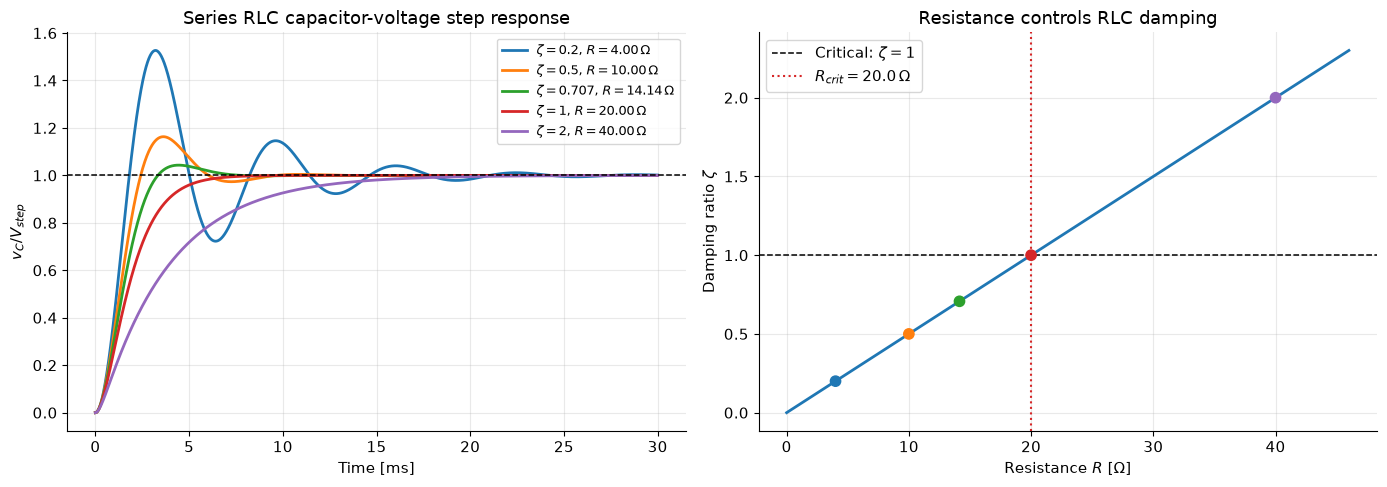

In [8]:
target_zetas = np.array([0.2, 0.5, 1 / np.sqrt(2), 1.0, 2.0])
resistances = 2 * target_zetas * np.sqrt(L_value / C_value)
rlc_time = np.linspace(0, 0.03, 3000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
print(" target zeta | R [ohm] |    Q    | poles [rad/s]")
print("-------------+---------+---------+--------------------------------")
for index, (zeta, resistance) in enumerate(zip(target_zetas, resistances)):
    capacitor_tf = ct.tf(
        [1.0],
        [L_value * C_value, resistance * C_value, 1.0],
    )
    response_time, capacitor_voltage = ct.step_response(capacitor_tf, T=rlc_time)
    axes[0].plot(
        1e3 * response_time,
        capacitor_voltage,
        color=COLORS[index],
        label=fr"$\zeta={zeta:.3g}$, $R={resistance:.2f}\,\Omega$",
    )
    quality_factor = 1 / (2 * zeta)
    print(
        f" {zeta:11.3f} | {resistance:7.2f} | {quality_factor:7.3f} | "
        f"{np.array2string(ct.poles(capacitor_tf), precision=1)}"
    )

axes[0].axhline(1, color="black", linestyle="--", linewidth=1.1)
axes[0].set_title("Series RLC capacitor-voltage step response")
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel(r"$v_C / V_{step}$")
axes[0].legend(fontsize=9)

resistance_axis = np.linspace(0, 1.15 * resistances.max(), 400)
zeta_axis = (resistance_axis / 2) * np.sqrt(C_value / L_value)
axes[1].plot(resistance_axis, zeta_axis, color=COLORS[0])
axes[1].scatter(resistances, target_zetas, c=COLORS[:len(target_zetas)], s=55, zorder=3)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1.1, label=r"Critical: $\zeta=1$")
axes[1].axvline(critical_resistance, color=COLORS[3], linestyle=":", linewidth=1.5,
                label=fr"$R_{{crit}}={critical_resistance:.1f}\,\Omega$")
axes[1].set_title("Resistance controls RLC damping")
axes[1].set_xlabel(r"Resistance $R$ [$\Omega$]")
axes[1].set_ylabel(r"Damping ratio $\zeta$")
axes[1].legend()

fig.tight_layout()
plt.show()

## 10. Poles, Zeros, and the Complex Plane

A rational transfer function can be factored as

$$G(s)=K\frac{\prod_i(s-z_i)}{\prod_k(s-p_k)},$$

where $z_i$ are **zeros** and $p_k$ are **poles**. Repeated roots have multiplicity greater than one.

A mode associated with a pole $p=\sigma+j\omega$ behaves like

$$e^{pt}=e^{\sigma t}(\cos\omega t+j\sin\omega t).$$

Therefore:

- $\sigma<0$: the mode decays, with envelope time constant approximately $1/|\sigma|$;
- $\sigma>0$: the mode grows;
- $|\omega|$: oscillation frequency in rad/s;
- poles nearest the imaginary axis are often **dominant** because they decay slowest.

For an underdamped second-order pair,

$$\omega_n=|p|,\qquad \zeta=-\frac{\operatorname{Re}(p)}{|p|}.$$

Thus constant $\omega_n$ forms a circle and constant $\zeta$ forms rays in the left half-plane. This circle relation applies directly to the complex pair; overdamped real roots have unequal magnitudes.

Zeros do not create autonomous modes, but they weight and reshape the modes visible between a chosen input and output. Their location can strongly affect rise, overshoot, phase, and even the initial direction of motion.

Example system poles: [-4.+0.j     -1.+2.8284j -1.-2.8284j]
Example system zeros: [-1.+0.j]


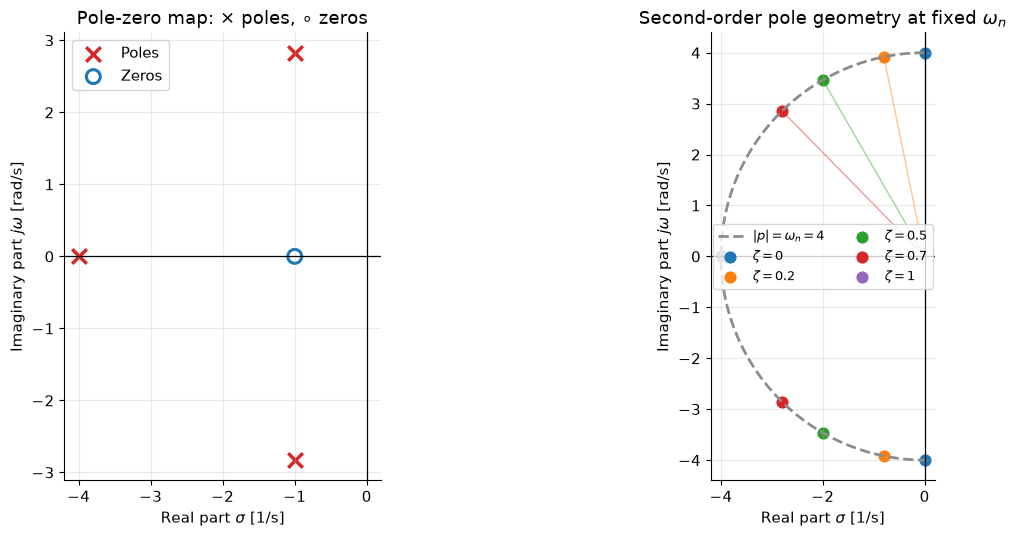

In [10]:
example_pz_system = 12 * (s_tf + 1) / ((s_tf + 4) * (s_tf**2 + 2 * s_tf + 9))
example_poles = ct.poles(example_pz_system)
example_zeros = ct.zeros(example_pz_system)
print("Example system poles:", example_poles)
print("Example system zeros:", example_zeros)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(example_poles.real, example_poles.imag, marker="x", s=110,
                linewidths=2.5, color=COLORS[3], label="Poles")
axes[0].scatter(example_zeros.real, example_zeros.imag, marker="o", s=100,
                facecolors="none", edgecolors=COLORS[0], linewidths=2.2, label="Zeros")
axes[0].axhline(0, color="black", linewidth=0.9)
axes[0].axvline(0, color="black", linewidth=0.9)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title(r"Pole-zero map: $\times$ poles, $\circ$ zeros")
axes[0].set_xlabel(r"Real part $\sigma$ [1/s]")
axes[0].set_ylabel(r"Imaginary part $j\omega$ [rad/s]")
axes[0].legend()

geometry_zetas = [0.0, 0.2, 0.5, 0.7, 1.0]
angle = np.linspace(np.pi / 2, 3 * np.pi / 2, 300)
axes[1].plot(omega_n_value * np.cos(angle), omega_n_value * np.sin(angle),
             color="0.55", linestyle="--", label=fr"$|p|=\omega_n={omega_n_value:g}$")
for index, zeta in enumerate(geometry_zetas):
    poles = np.roots([1, 2 * zeta * omega_n_value, omega_n_value**2])
    axes[1].scatter(poles.real, poles.imag, color=COLORS[index], s=60,
                    label=fr"$\zeta={zeta:g}$")
    if zeta < 1:
        axes[1].plot([0, poles[0].real], [0, poles[0].imag],
                     color=COLORS[index], alpha=0.45, linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.9)
axes[1].axvline(0, color="black", linewidth=0.9)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title(r"Second-order pole geometry at fixed $\omega_n$")
axes[1].set_xlabel(r"Real part $\sigma$ [1/s]")
axes[1].set_ylabel(r"Imaginary part $j\omega$ [rad/s]")
axes[1].legend(fontsize=9, ncols=2)

fig.tight_layout()
plt.show()

## 11. Poles and System Stability

For a proper, minimal, continuous-time rational transfer function:

- **BIBO stable:** every pole lies strictly in the open left half-plane (LHP);
- **unstable:** at least one pole lies in the right half-plane (RHP), or a repeated pole lies on the imaginary axis;
- **marginal natural response:** simple imaginary-axis poles with all other poles in the LHP can produce bounded, nondecaying oscillation, but this is not asymptotic stability and generally is not BIBO stability.

**Internal stability** is stronger than stability of one displayed transfer function. An exact unstable pole-zero cancellation may hide an unstable internal mode; physical parameter error makes such cancellations especially unsafe.

### Characteristic equation and Routh-Hurwitz idea

Closed-loop stability is determined by the characteristic polynomial. For

$$a_3s^3+a_2s^2+a_1s+a_0,$$

the first Routh-column entries are

$$a_3,\quad a_2,\quad \frac{a_2a_1-a_3a_0}{a_2},\quad a_0.$$

With $a_3>0$, all must be positive for strict LHP stability. In particular, positive coefficients alone are not enough; the cubic also needs $a_2a_1>a_3a_0$. Routh-Hurwitz counts RHP roots without explicitly solving for them.

Stable: poles at -1 +/- j1.73
  asymptotically stable; poles = [-1.+1.7321j -1.-1.7321j]
Imaginary-axis pair: poles at +/- j2
  boundary poles: inspect multiplicity/BIBO behavior; poles = [-0.+2.j  0.-2.j]
Unstable: poles at 0.2 +/- j1.99
  unstable; poles = [0.2+1.99j 0.2-1.99j]


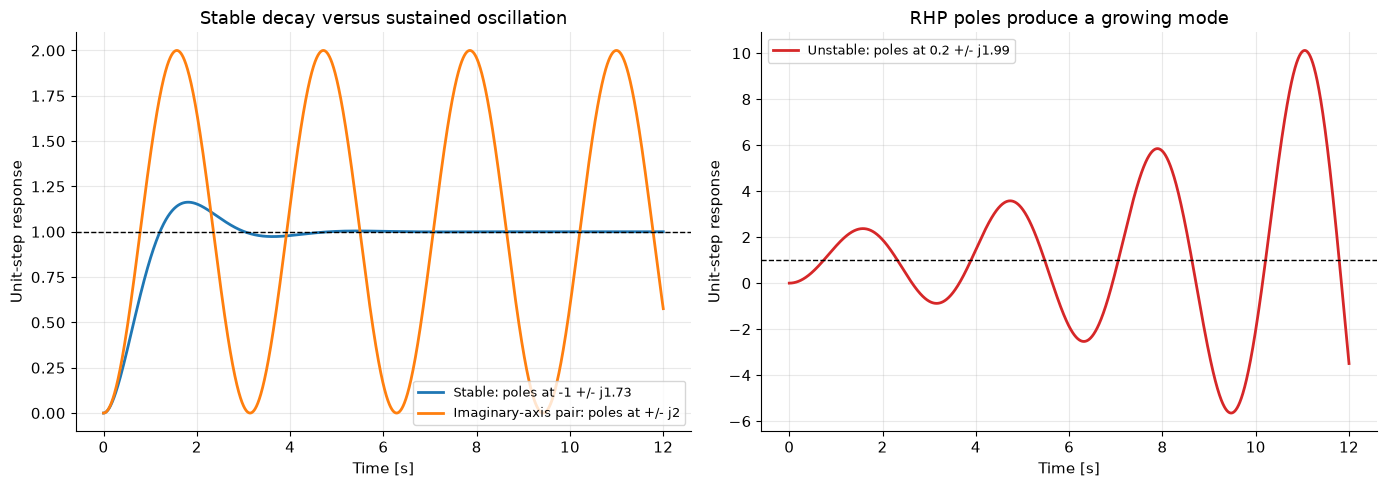

In [11]:
def pole_location_class(system, tolerance=1e-9):
    real_parts = ct.poles(system).real
    if np.any(real_parts > tolerance):
        return "unstable"
    if np.all(real_parts < -tolerance):
        return "asymptotically stable"
    return "boundary poles: inspect multiplicity/BIBO behavior"


stability_systems = {
    "Stable: poles at -1 +/- j1.73": ct.tf([4], [1, 2, 4]),
    "Imaginary-axis pair: poles at +/- j2": ct.tf([4], [1, 0, 4]),
    "Unstable: poles at 0.2 +/- j1.99": ct.tf([4], [1, -0.4, 4]),
}
for name, system in stability_systems.items():
    print(f"{name}\n  {pole_location_class(system)}; poles = {ct.poles(system)}")

stable_time = np.linspace(0, 12, 2200)
unstable_time = np.linspace(0, 12, 2200)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for index, name in enumerate(list(stability_systems)[:2]):
    response_time, response = ct.step_response(stability_systems[name], T=stable_time)
    axes[0].plot(response_time, response, color=COLORS[index], label=name)
axes[0].axhline(1, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Stable decay versus sustained oscillation")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Unit-step response")
axes[0].legend(fontsize=9)

unstable_name = list(stability_systems)[2]
response_time, response = ct.step_response(stability_systems[unstable_name], T=unstable_time)
axes[1].plot(response_time, response, color=COLORS[3], label=unstable_name)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[1].set_title("RHP poles produce a growing mode")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Unit-step response")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

## 12. Pole Locations and Response Speed

For a dominant pole $p=\sigma+j\omega$:

- the envelope is $e^{\sigma t}$, so more-negative $\sigma$ means faster decay;
- $|\omega|$ sets oscillation frequency;
- a common 2% settling estimate for a dominant mode is $t_s\approx4/|\sigma|$.

A pole farther left is usually faster **when comparing similar, stable systems without problematic zeros, delays, hidden slow modes, or actuator limits**. In a high-order model, the stable poles closest to the imaginary axis tend to dominate late-time behavior. A dominant-pole approximation is most credible when neglected poles are several times farther left and are not amplified by zeros or residues.

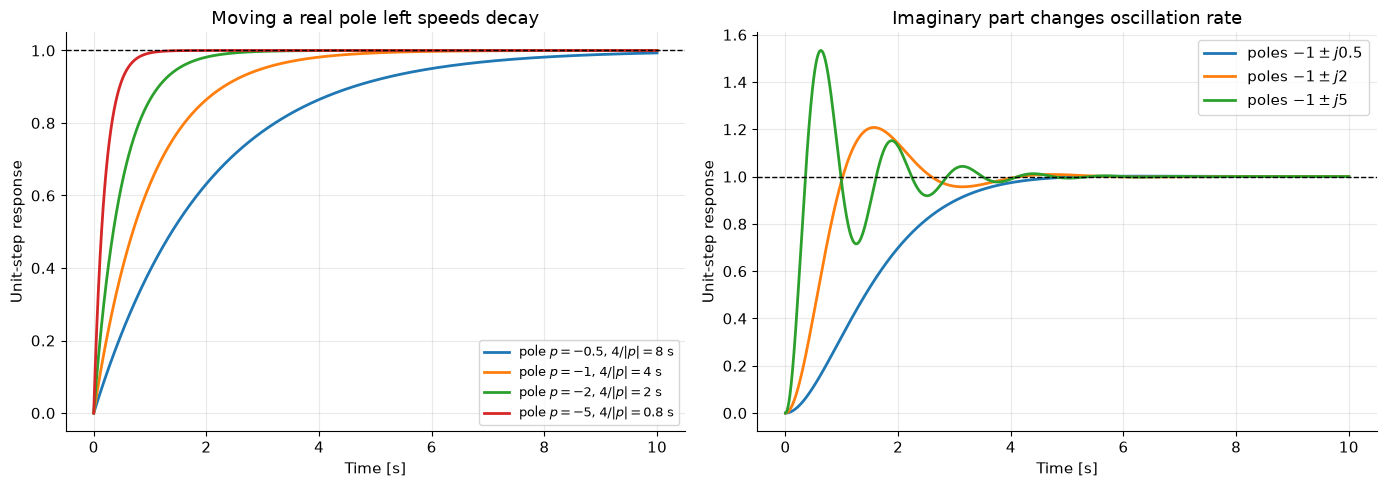

In [12]:
speed_time = np.linspace(0, 10, 1800)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pole_rates = [0.5, 1.0, 2.0, 5.0]
for index, rate in enumerate(pole_rates):
    first_order = rate / (s_tf + rate)
    response_time, response = ct.step_response(first_order, T=speed_time)
    axes[0].plot(response_time, response, color=COLORS[index],
                 label=fr"pole $p={-rate:g}$, $4/|p|={4/rate:g}$ s")
axes[0].axhline(1, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Moving a real pole left speeds decay")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Unit-step response")
axes[0].legend(fontsize=9)

fixed_sigma = -1.0
imaginary_parts = [0.5, 2.0, 5.0]
for index, omega in enumerate(imaginary_parts):
    denominator = [1.0, -2 * fixed_sigma, fixed_sigma**2 + omega**2]
    oscillatory_system = ct.tf([fixed_sigma**2 + omega**2], denominator)
    response_time, response = ct.step_response(oscillatory_system, T=speed_time)
    axes[1].plot(response_time, response, color=COLORS[index],
                 label=fr"poles $-1\pm j{omega:g}$")
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Imaginary part changes oscillation rate")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Unit-step response")
axes[1].legend()

fig.tight_layout()
plt.show()

## 13. Zeros and Their Effect on Response

Zeros shape how pole modes combine in a particular input-output channel.

- An LHP zero is **minimum phase** and often adds phase lead and a faster-looking initial response.
- An RHP zero is **nonminimum phase**. It contributes extra phase lag and commonly produces an inverse response: the output initially moves opposite its final direction.
- A zero close to a pole can reduce that mode's visible residue, but exact cancellation is fragile.
- Zeros do not determine BIBO stability; poles do. However, an unstable pole canceled in one transfer function can remain as a dangerous hidden internal mode.

A RHP zero and its mirrored LHP zero have the same frequency-response magnitude factor on $s=j\omega$, but different phase. This imposes a fundamental speed-versus-robustness limitation on nonminimum-phase plants.

The following systems have the **same poles and the same DC gain**. Only their zeros differ, so the transient differences come from numerator dynamics.

No finite zero    : DC gain=1.00, zeros=[], poles=[-4.+0.j -2.+0.j]
LHP zero at -1    : DC gain=1.00, zeros=[-1.+0.j], poles=[-4.+0.j -2.+0.j]
RHP zero at +1    : DC gain=1.00, zeros=[1.+0.j], poles=[-4.+0.j -2.+0.j]


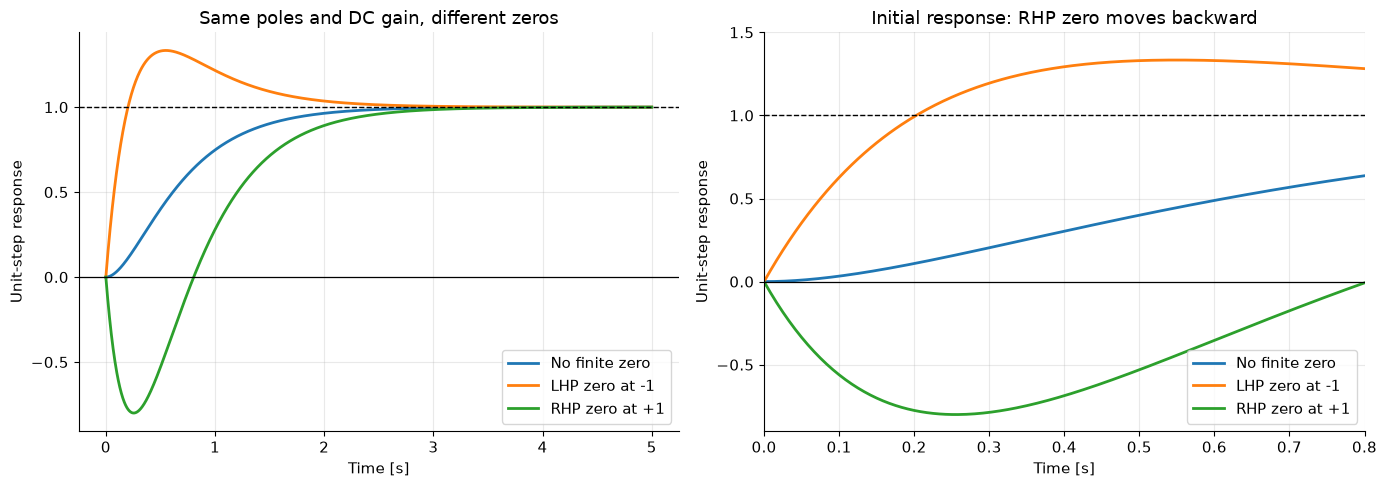

In [13]:
common_denominator = (s_tf + 2) * (s_tf + 4)
zero_comparison = {
    "No finite zero": 8 / common_denominator,
    "LHP zero at -1": 8 * (s_tf + 1) / common_denominator,
    "RHP zero at +1": 8 * (1 - s_tf) / common_denominator,
}
zero_time = np.linspace(0, 5, 1800)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for index, (label, system) in enumerate(zero_comparison.items()):
    response_time, response = ct.step_response(system, T=zero_time)
    print(
        f"{label:18s}: DC gain={ct.dcgain(system):.2f}, "
        f"zeros={ct.zeros(system)}, poles={ct.poles(system)}"
    )
    for axis in axes:
        axis.plot(response_time, response, color=COLORS[index], label=label)

for axis in axes:
    axis.axhline(0, color="black", linewidth=0.9)
    axis.axhline(1, color="black", linestyle="--", linewidth=1)
    axis.set_xlabel("Time [s]")
    axis.set_ylabel("Unit-step response")
axes[0].set_title("Same poles and DC gain, different zeros")
axes[0].legend()
axes[1].set_xlim(0, 0.8)
axes[1].set_ylim(-0.9, 1.5)
axes[1].set_title("Initial response: RHP zero moves backward")
axes[1].legend()

fig.tight_layout()
plt.show()

## 14. Steady-State Error and System Type

For unity negative feedback with loop transfer $L(s)=C(s)G(s)$,

$$E(s)=\frac{R(s)}{1+L(s)}.$$

If the relevant closed-loop signals are stable and the final-value theorem applies,

$$e_{ss}=\lim_{t\to\infty}e(t)=\lim_{s\to0}sE(s).$$

Define the low-frequency error constants

$$K_p=\lim_{s\to0}L(s),\qquad
K_v=\lim_{s\to0}sL(s),\qquad
K_a=\lim_{s\to0}s^2L(s).$$

For unit step, ramp, and parabolic commands $1$, $t$, and $t^2/2$:

$$e_{step}=\frac{1}{1+K_p},\qquad
e_{ramp}=\frac{1}{K_v},\qquad
e_{parabolic}=\frac{1}{K_a}.$$

The **system type** is the number of uncanceled poles at the origin in $L(s)$.

| Type | Step error | Ramp error | Parabolic error |
|---:|---:|---:|---:|
| 0 | finite | infinite | infinite |
| 1 | zero | finite | infinite |
| 2 | zero | zero | finite |

Adding integral action improves low-frequency tracking and constant-disturbance rejection, but it adds phase lag and can cause **integrator windup** when an actuator saturates.

Final-value-theorem predictions (step, ramp, parabolic):
Type 0: (0.5, inf, inf), closed-loop poles=[-2.5+1.323j -2.5-1.323j]
Type 1: (0.0, 1.0, inf), closed-loop poles=[-7.464+0.j -0.536+0.j]
Type 2: (0.0, 0.0, 1.0), closed-loop poles=[-3.13 +0.j    -0.435+1.043j -0.435-1.043j]


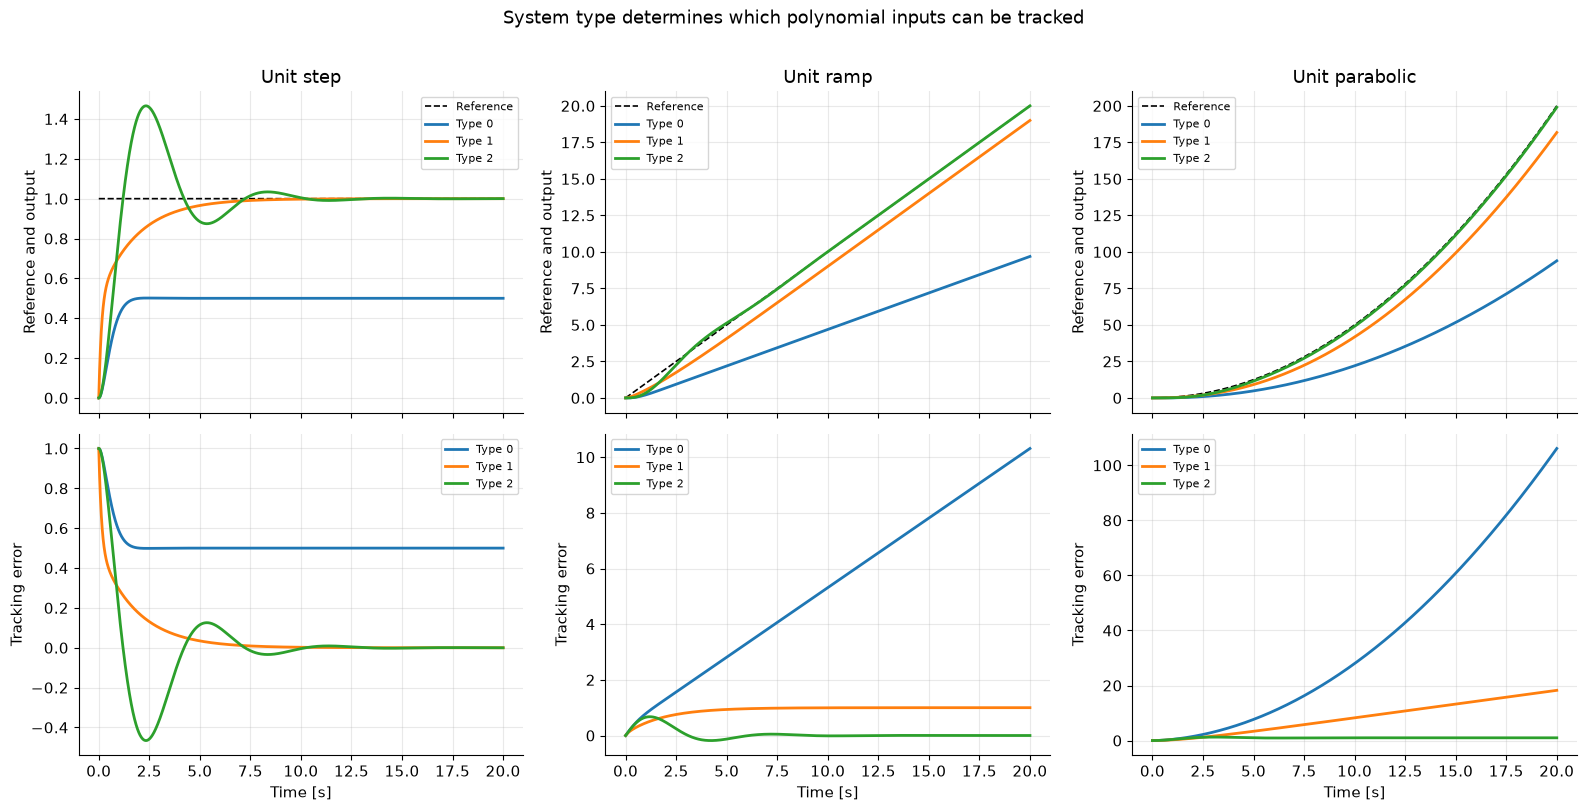

In [14]:
loop_by_type = {
    "Type 0": 4 / ((s_tf + 1) * (s_tf + 4)),
    "Type 1": 4 * (s_tf + 1) / (s_tf * (s_tf + 4)),
    "Type 2": 4 * (s_tf + 1) / (s_tf**2 * (s_tf + 4)),
}
predicted_errors = {
    "Type 0": (0.5, np.inf, np.inf),
    "Type 1": (0.0, 1.0, np.inf),
    "Type 2": (0.0, 0.0, 1.0),
}
tracking_time = np.linspace(0, 20, 4000)
commands = {
    "Unit step": np.ones_like(tracking_time),
    "Unit ramp": tracking_time,
    "Unit parabolic": 0.5 * tracking_time**2,
}

print("Final-value-theorem predictions (step, ramp, parabolic):")
for loop_name, loop in loop_by_type.items():
    closed_loop = ct.feedback(loop, 1)
    print(
        f"{loop_name}: {predicted_errors[loop_name]}, "
        f"closed-loop poles={np.array2string(ct.poles(closed_loop), precision=3)}"
    )

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex="col")
for column, (command_name, command) in enumerate(commands.items()):
    axes[0, column].plot(tracking_time, command, color="black", linestyle="--",
                         linewidth=1.2, label="Reference")
    for index, (loop_name, loop) in enumerate(loop_by_type.items()):
        closed_loop = ct.feedback(loop, 1)
        response = ct.forced_response(closed_loop, T=tracking_time, U=command)
        output = np.asarray(response.outputs).squeeze()
        error = command - output
        axes[0, column].plot(tracking_time, output, color=COLORS[index], label=loop_name)
        axes[1, column].plot(tracking_time, error, color=COLORS[index], label=loop_name)
    axes[0, column].set_title(command_name)
    axes[0, column].set_ylabel("Reference and output")
    axes[1, column].set_ylabel("Tracking error")
    axes[1, column].set_xlabel("Time [s]")
    axes[0, column].legend(fontsize=8)
    axes[1, column].legend(fontsize=8)

fig.suptitle("System type determines which polynomial inputs can be tracked", y=1.01)
fig.tight_layout()
plt.show()

## 15. Open-Loop and Closed-Loop Feedback

Let the plant be $P$, controller be $C$, and loop transfer be $L=PC$ under unity negative feedback. Define

$$S(s)=\frac{1}{1+L(s)}\quad\text{(sensitivity)},$$

$$T(s)=\frac{L(s)}{1+L(s)}\quad\text{(complementary sensitivity)},$$

so $S+T=1$.

Important closed-loop paths are:

| Input | Output path |
|---|---|
| Reference $r$ to output $y$ | $T$ |
| Plant-input disturbance $d$ to $y$ | $PS$ |
| Measurement noise $n$ to $y$ | $-T$ |
| Reference $r$ to error $e$ | $S$ |

Large $|L|$ at low frequency makes $|S|$ small, improving tracking and rejecting slow disturbances. At high frequency, making $|T|$ small reduces sensor-noise transmission and unmodeled-dynamics risk. Because $S+T=1$, feedback design is fundamentally a frequency-dependent tradeoff, not unlimited error reduction.

Feedback can also speed response and reduce parameter sensitivity, but it can destabilize a system if loop phase and gain make $1+L(s)$ vanish in the wrong region.

S(0) = 0.200
T(0) = 0.800
S(0) + T(0) = 1.000
Closed-loop poles: [-5.+0.j]


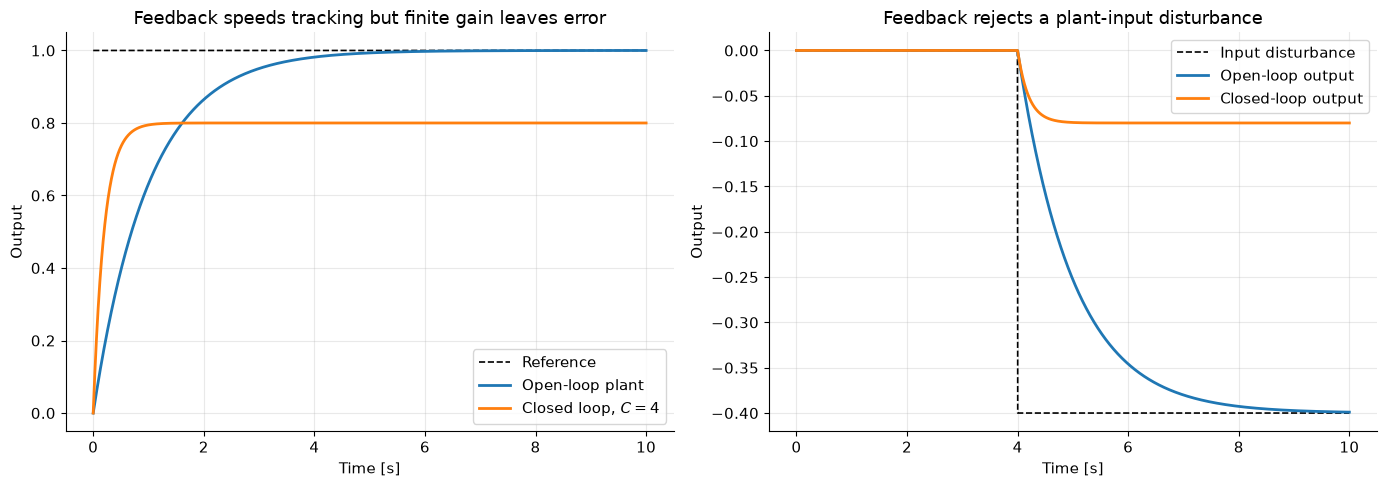

In [15]:
feedback_plant = 1 / (s_tf + 1)
feedback_controller = 4.0
loop_transfer = feedback_controller * feedback_plant
sensitivity = ct.feedback(1, loop_transfer)
complementary_sensitivity = ct.feedback(loop_transfer, 1)
disturbance_path = feedback_plant * sensitivity

print(f"S(0) = {ct.dcgain(sensitivity):.3f}")
print(f"T(0) = {ct.dcgain(complementary_sensitivity):.3f}")
print(f"S(0) + T(0) = {ct.dcgain(sensitivity + complementary_sensitivity):.3f}")
print("Closed-loop poles:", ct.poles(complementary_sensitivity))

feedback_time = np.linspace(0, 10, 2000)
reference = np.ones_like(feedback_time)
disturbance = np.where(feedback_time >= 4.0, -0.4, 0.0)

open_tracking = ct.forced_response(feedback_plant, T=feedback_time, U=reference).outputs.squeeze()
closed_tracking = ct.forced_response(
    complementary_sensitivity, T=feedback_time, U=reference
).outputs.squeeze()
open_disturbance = ct.forced_response(
    feedback_plant, T=feedback_time, U=disturbance
).outputs.squeeze()
closed_disturbance = ct.forced_response(
    disturbance_path, T=feedback_time, U=disturbance
).outputs.squeeze()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(feedback_time, reference, "k--", linewidth=1.2, label="Reference")
axes[0].plot(feedback_time, open_tracking, label="Open-loop plant")
axes[0].plot(feedback_time, closed_tracking, label="Closed loop, $C=4$")
axes[0].set_title("Feedback speeds tracking but finite gain leaves error")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Output")
axes[0].legend()

axes[1].plot(feedback_time, disturbance, "k--", linewidth=1.2, label="Input disturbance")
axes[1].plot(feedback_time, open_disturbance, label="Open-loop output")
axes[1].plot(feedback_time, closed_disturbance, label="Closed-loop output")
axes[1].set_title("Feedback rejects a plant-input disturbance")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Output")
axes[1].legend()

fig.tight_layout()
plt.show()

## 16. Root-Locus Analysis

The **root locus** shows every closed-loop pole location produced as a real gain $K$ varies from $0$ to $\infty$ in

$$1+K G(s)H(s)=0.$$

Core rules:

- the number of branches equals the number of open-loop poles;
- branches start at open-loop poles when $K=0$;
- branches end at open-loop zeros, with extra branches going to infinity;
- the locus is symmetric about the real axis;
- a real-axis point is on the locus when an odd number of real open-loop poles and zeros lie to its right;
- angle and magnitude conditions determine whether a point is on the locus and the required gain.

For

$$G(s)=\frac{1}{s(s+2)},$$

the unity-feedback characteristic equation is

$$s^2+2s+K=0,$$

so

$$s=-1\pm\sqrt{1-K}.$$

The branches meet at $-1$ for $K=1$, then move vertically as a complex pair. For $K>1$, $\omega_n=\sqrt{K}$ and $\zeta=1/\sqrt{K}$: increasing gain increases natural frequency but decreases damping.

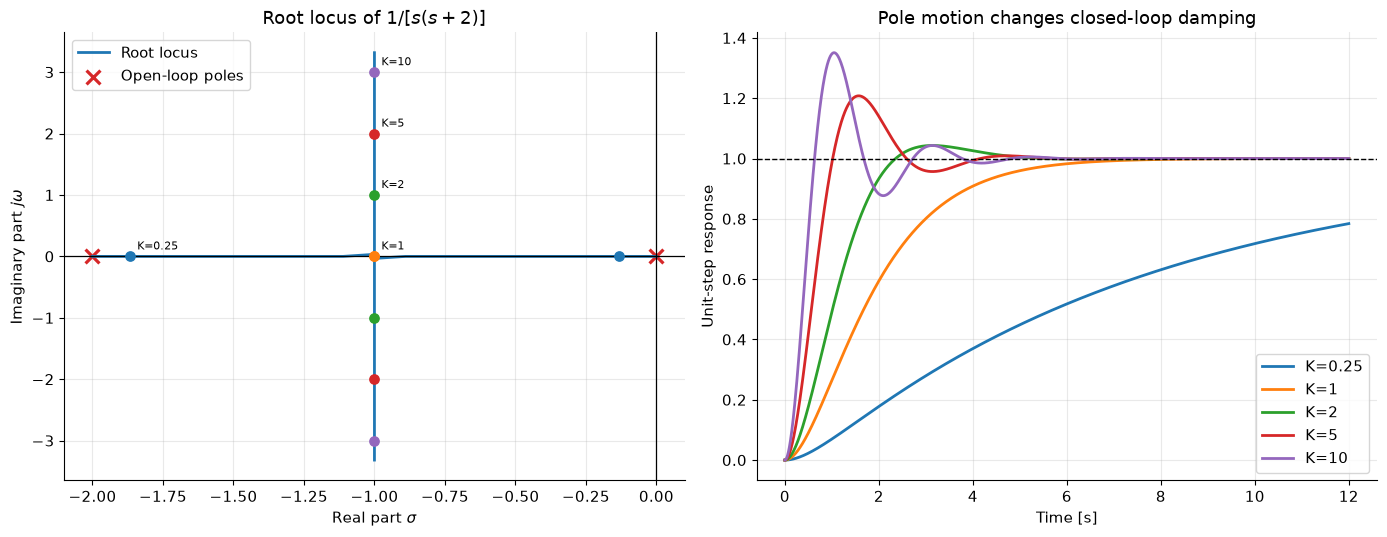

In [16]:
gain_sweep = np.linspace(0, 12, 900)
root_branch_1 = np.empty(gain_sweep.size, dtype=complex)
root_branch_2 = np.empty(gain_sweep.size, dtype=complex)
for index, gain in enumerate(gain_sweep):
    roots = np.roots([1.0, 2.0, gain])
    root_branch_1[index], root_branch_2[index] = roots

selected_gains = [0.25, 1.0, 2.0, 5.0, 10.0]
root_time = np.linspace(0, 12, 2500)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(root_branch_1.real, root_branch_1.imag, color=COLORS[0])
axes[0].plot(root_branch_2.real, root_branch_2.imag, color=COLORS[0], label="Root locus")
axes[0].scatter([0, -2], [0, 0], marker="x", s=100, linewidths=2.3,
                color=COLORS[3], label="Open-loop poles")
for index, gain in enumerate(selected_gains):
    roots = np.roots([1.0, 2.0, gain])
    axes[0].scatter(roots.real, roots.imag, color=COLORS[index], s=45, zorder=3)
    axes[0].annotate(f"K={gain:g}", (roots[0].real, roots[0].imag),
                     xytext=(5, 5), textcoords="offset points", fontsize=8)
    closed_loop = ct.tf([gain], [1.0, 2.0, gain])
    response_time, response = ct.step_response(closed_loop, T=root_time)
    axes[1].plot(response_time, response, color=COLORS[index], label=f"K={gain:g}")

axes[0].axhline(0, color="black", linewidth=0.9)
axes[0].axvline(0, color="black", linewidth=0.9)
axes[0].set_title(r"Root locus of $1/[s(s+2)]$")
axes[0].set_xlabel(r"Real part $\sigma$")
axes[0].set_ylabel(r"Imaginary part $j\omega$")
axes[0].legend()
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Pole motion changes closed-loop damping")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Unit-step response")
axes[1].legend()

fig.tight_layout()
plt.show()

## 17. Frequency-Response Analysis

For a stable sinusoidal steady state, evaluate the transfer function on the imaginary axis:

$$G(j\omega)=|G(j\omega)|e^{j\angle G(j\omega)}.$$

A **Bode plot** shows magnitude (usually dB) and phase versus logarithmic frequency. It exposes bandwidth, resonance, roll-off, delay, and model uncertainty across time scales.

Important loop quantities:

- **gain crossover** $\omega_{gc}$: $|L(j\omega)|=1$ (0 dB);
- **phase margin**: additional phase lag at $\omega_{gc}$ required to reach $-180^\circ$;
- **phase crossover** $\omega_{pc}$: $\angle L(j\omega)=-180^\circ$;
- **gain margin**: factor by which loop gain can increase at $\omega_{pc}$ before the Nyquist curve reaches $-1$;
- **closed-loop bandwidth**: often the first frequency where $|T|$ falls 3 dB below its low-frequency value;
- **resonant peak** $M_r$: maximum of $|T(j\omega)|$.

Larger bandwidth usually means faster response, but it increases exposure to noise, delay, unmodeled high-frequency dynamics, and actuator demand. Gain and phase margins are useful robustness indicators, not universal guarantees.

The **Nyquist criterion** applies the argument principle to $1+L(s)$. Encirclements of the critical point $-1$ are combined with the number of open-loop RHP poles to determine the number of closed-loop RHP poles. If $L$ has no RHP poles, a stable closed loop requires no net encirclement of $-1$ under the standard contour convention.

Gain margin       = 12.000 (21.58 dB)
Phase crossover   = 4.472 rad/s
Phase margin      = 60.42 deg
Gain crossover    = 0.907 rad/s
Closed bandwidth  = 1.534 rad/s (grid estimate)
Resonant peak     = 1.020 at 0.617 rad/s
Closed-loop poles = [-10.2372+0.j      -0.8814+1.0848j  -0.8814-1.0848j]


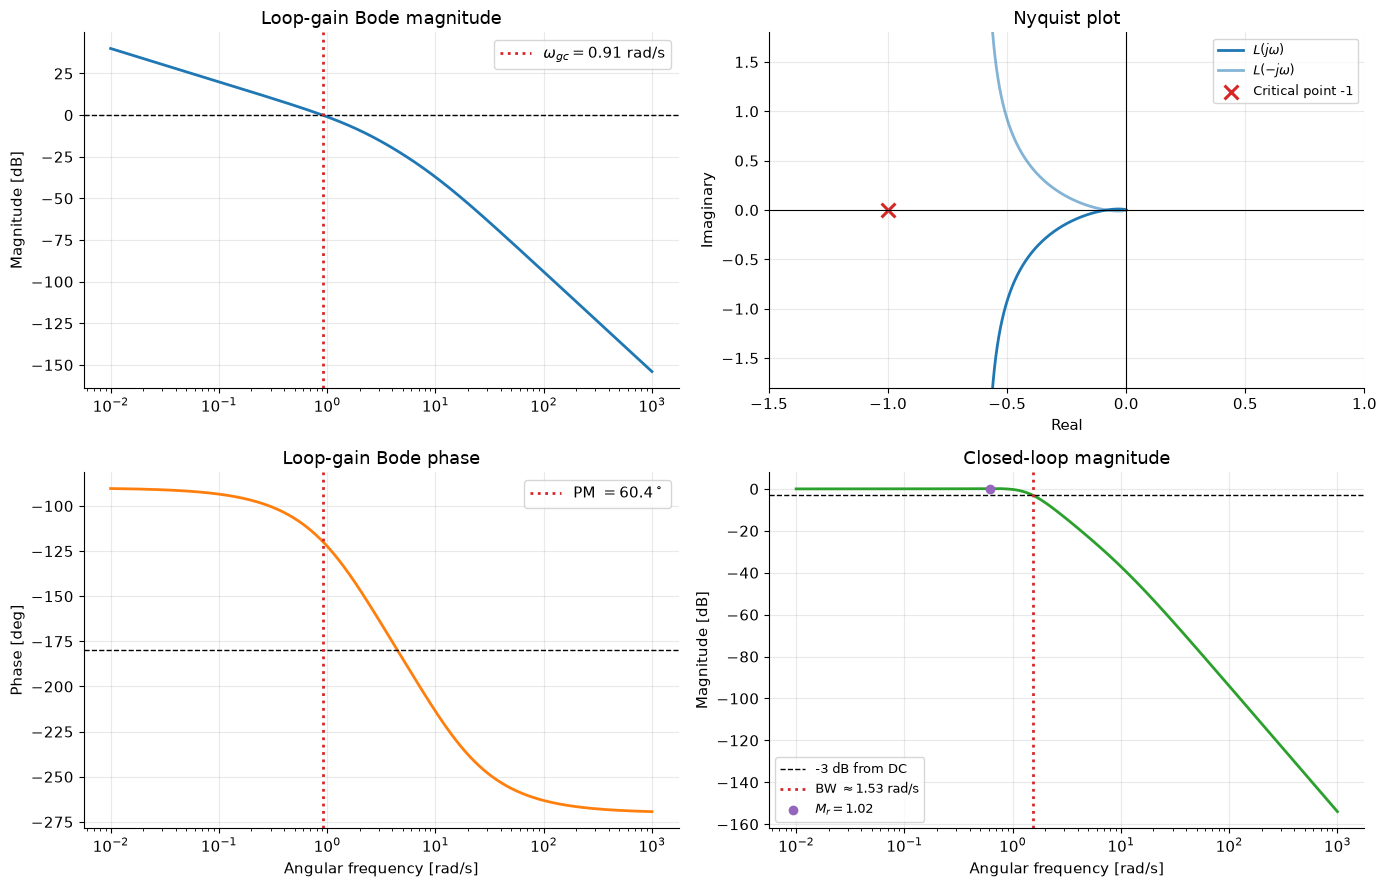

In [17]:
frequency_loop = 20 / (s_tf * (s_tf + 2) * (s_tf + 10))
frequency_closed_loop = ct.feedback(frequency_loop, 1)
omega = np.logspace(-2, 3, 3000)
loop_response = np.array([ct.evalfr(frequency_loop, 1j * value) for value in omega])
closed_response = np.array([ct.evalfr(frequency_closed_loop, 1j * value) for value in omega])
loop_magnitude_db = 20 * np.log10(np.abs(loop_response))
loop_phase_deg = np.unwrap(np.angle(loop_response)) * 180 / np.pi
closed_magnitude = np.abs(closed_response)

gain_margin, phase_margin, phase_cross_frequency, gain_cross_frequency = ct.margin(frequency_loop)
dc_magnitude = abs(ct.dcgain(frequency_closed_loop))
bandwidth_indices = np.flatnonzero(closed_magnitude <= dc_magnitude / np.sqrt(2))
bandwidth = omega[bandwidth_indices[0]] if bandwidth_indices.size else np.nan
resonant_index = int(np.argmax(closed_magnitude))
resonant_peak = closed_magnitude[resonant_index]
resonant_frequency = omega[resonant_index]

print(f"Gain margin       = {gain_margin:.3f} ({20*np.log10(gain_margin):.2f} dB)")
print(f"Phase crossover   = {phase_cross_frequency:.3f} rad/s")
print(f"Phase margin      = {phase_margin:.2f} deg")
print(f"Gain crossover    = {gain_cross_frequency:.3f} rad/s")
print(f"Closed bandwidth  = {bandwidth:.3f} rad/s (grid estimate)")
print(f"Resonant peak     = {resonant_peak:.3f} at {resonant_frequency:.3f} rad/s")
print("Closed-loop poles =", ct.poles(frequency_closed_loop))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].semilogx(omega, loop_magnitude_db, color=COLORS[0])
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0, 0].axvline(gain_cross_frequency, color=COLORS[3], linestyle=":",
                   label=fr"$\omega_{{gc}}={gain_cross_frequency:.2f}$ rad/s")
axes[0, 0].set_title("Loop-gain Bode magnitude")
axes[0, 0].set_ylabel("Magnitude [dB]")
axes[0, 0].legend()

axes[1, 0].semilogx(omega, loop_phase_deg, color=COLORS[1])
axes[1, 0].axhline(-180, color="black", linestyle="--", linewidth=1)
axes[1, 0].axvline(gain_cross_frequency, color=COLORS[3], linestyle=":",
                   label=fr"PM $={phase_margin:.1f}^\circ$")
axes[1, 0].set_title("Loop-gain Bode phase")
axes[1, 0].set_xlabel("Angular frequency [rad/s]")
axes[1, 0].set_ylabel("Phase [deg]")
axes[1, 0].legend()

axes[0, 1].plot(loop_response.real, loop_response.imag, color=COLORS[0], label=r"$L(j\omega)$")
axes[0, 1].plot(loop_response.real, -loop_response.imag, color=COLORS[0], alpha=0.55,
                label=r"$L(-j\omega)$")
axes[0, 1].scatter([-1], [0], marker="x", s=100, linewidths=2.2,
                   color=COLORS[3], label="Critical point -1")
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].axvline(0, color="black", linewidth=0.8)
axes[0, 1].set_xlim(-1.5, 1.0)
axes[0, 1].set_ylim(-1.8, 1.8)
axes[0, 1].set_title("Nyquist plot")
axes[0, 1].set_xlabel("Real")
axes[0, 1].set_ylabel("Imaginary")
axes[0, 1].legend(fontsize=9)

axes[1, 1].semilogx(omega, 20 * np.log10(closed_magnitude), color=COLORS[2])
axes[1, 1].axhline(20 * np.log10(dc_magnitude / np.sqrt(2)), color="black",
                   linestyle="--", linewidth=1, label="-3 dB from DC")
axes[1, 1].axvline(bandwidth, color=COLORS[3], linestyle=":",
                   label=fr"BW $\approx{bandwidth:.2f}$ rad/s")
axes[1, 1].scatter([resonant_frequency], [20 * np.log10(resonant_peak)],
                   color=COLORS[4], zorder=3, label=fr"$M_r={resonant_peak:.2f}$")
axes[1, 1].set_title("Closed-loop magnitude")
axes[1, 1].set_xlabel("Angular frequency [rad/s]")
axes[1, 1].set_ylabel("Magnitude [dB]")
axes[1, 1].legend(fontsize=9)

fig.tight_layout()
plt.show()

## 18. PID Controller Design

The ideal parallel PID law is

$$u(t)=K_pe(t)+K_i\int e(t)\,dt+K_d\frac{de(t)}{dt},$$

or

$$C(s)=K_p+\frac{K_i}{s}+K_ds.$$

An ideal derivative is improper and amplifies high-frequency noise, so implementations use a filtered derivative such as

$$C_D(s)=\frac{K_d s}{\tau_f s+1}.$$

| Action | Main benefit | Main risk or cost |
|---|---|---|
| P | Faster correction; lowers error | Does not generally remove step error; too much can destabilize |
| I | Removes constant error and rejects constant disturbances | Phase lag, overshoot, slow recovery, windup |
| D | Adds damping/phase lead; anticipates trend | Noise amplification and derivative kick |
| PI | Common tracking/regulation choice | Must manage windup and reduced phase margin |
| PD | Improves transient shape without adding an integrator | Cannot guarantee zero constant error |
| PID | Flexible balance of speed, damping, and zero error | More tuning and implementation complexity |

Practical implementations commonly include:

- **anti-windup** by integrator clamping or back-calculation during saturation;
- derivative action on measured output instead of error to avoid setpoint kick;
- derivative filtering;
- setpoint weighting or a two-degree-of-freedom structure so tracking and disturbance response can be shaped differently;
- explicit checks of actuator magnitude, rate, sampling, noise, and robustness.

The same gains cannot be judged from output response alone: control effort matters.

Controller comparison (2% settling measured over the displayed interval)
name | final y | overshoot [%] | settling [s] | max |u|
-----+---------+---------------+--------------+--------
   P |   0.667 |         31.34 |        6.362 |   2.00
  PI |   1.000 |         19.30 |        8.803 |   2.13
  PD |   0.667 |         16.04 |        2.901 |  18.00
 PID |   1.000 |          0.00 |        6.472 |  18.00


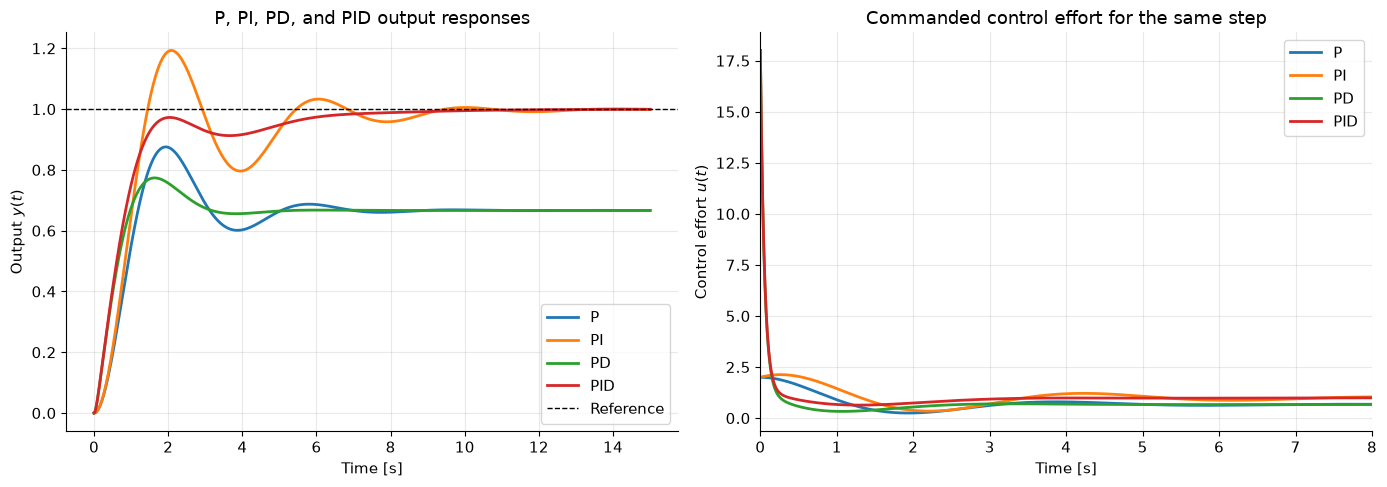

In [18]:
pid_plant = 1 / (s_tf**2 + 1.2 * s_tf + 1)
Kp, Ki, Kd, derivative_filter_time = 2.0, 1.0, 0.8, 0.05
filtered_derivative = Kd * s_tf / (derivative_filter_time * s_tf + 1)
controllers = {
    "P": Kp,
    "PI": Kp + Ki / s_tf,
    "PD": Kp + filtered_derivative,
    "PID": Kp + Ki / s_tf + filtered_derivative,
}
pid_time = np.linspace(0, 15, 3000)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

print("Controller comparison (2% settling measured over the displayed interval)")
print("name | final y | overshoot [%] | settling [s] | max |u|")
print("-----+---------+---------------+--------------+--------")
for index, (name, controller) in enumerate(controllers.items()):
    output_path = ct.feedback(controller * pid_plant, 1)
    effort_path = ct.feedback(controller, pid_plant)
    output_response = ct.step_response(output_path, T=pid_time)
    effort_response = ct.step_response(effort_path, T=pid_time)
    output = np.asarray(output_response.outputs).squeeze()
    effort = np.asarray(effort_response.outputs).squeeze()
    final_output = float(ct.dcgain(output_path))
    _, _, overshoot, settling = measured_step_metrics(
        pid_time, output, final_value=final_output
    )
    print(
        f"{name:>4s} | {final_output:7.3f} | {overshoot:13.2f} | "
        f"{settling:12.3f} | {np.max(np.abs(effort)):6.2f}"
    )
    axes[0].plot(pid_time, output, color=COLORS[index], label=name)
    axes[1].plot(pid_time, effort, color=COLORS[index], label=name)

axes[0].axhline(1, color="black", linestyle="--", linewidth=1, label="Reference")
axes[0].set_title("P, PI, PD, and PID output responses")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Output $y(t)$")
axes[0].legend()
axes[1].set_title("Commanded control effort for the same step")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Control effort $u(t)$")
axes[1].set_xlim(0, 8)
axes[1].legend()

fig.tight_layout()
plt.show()

## 19. State-Space Modeling

A continuous-time LTI state-space model is

$$\dot{x}=Ax+Bu,\qquad y=Cx+Du.$$

The state vector $x$ contains enough information to determine future motion given future input. State variables often correspond to stored-energy variables, such as position and velocity or inductor current and capacitor voltage.

For initial state $x(0)$,

$$x(t)=e^{At}x(0)+\int_0^t e^{A(t-\tau)}Bu(\tau)\,d\tau.$$

The transfer matrix is

$$G(s)=C(sI-A)^{-1}B+D.$$

Eigenvalues of $A$ are the system's internal modes. They equal the poles of a minimal realization, but uncontrollable or unobservable modes can be absent from a particular transfer function. State-space form naturally supports initial conditions, multiple inputs and outputs (MIMO), observers, and modern control design.

For the mass-spring-damper model, choose $x_1=x$ and $x_2=\dot{x}$:

$$
\begin{bmatrix}\dot{x}_1\\\dot{x}_2\end{bmatrix}
=
\begin{bmatrix}0&1\\-k/m&-b/m\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}
+
\begin{bmatrix}0\\1/m\end{bmatrix}F,
\qquad y=\begin{bmatrix}1&0\end{bmatrix}x.
$$

A =
 [[ 0.   1. ]
 [-4.  -0.8]]
B =
 [[0.]
 [1.]]
C =
 [[1. 0.]]
Eigenvalues of A: [-0.4+1.9596j -0.4-1.9596j]
Transfer function recovered from state space: <TransferFunction>: sys[304]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        + 1
  ---------------
  s^2 + 0.8 s + 4


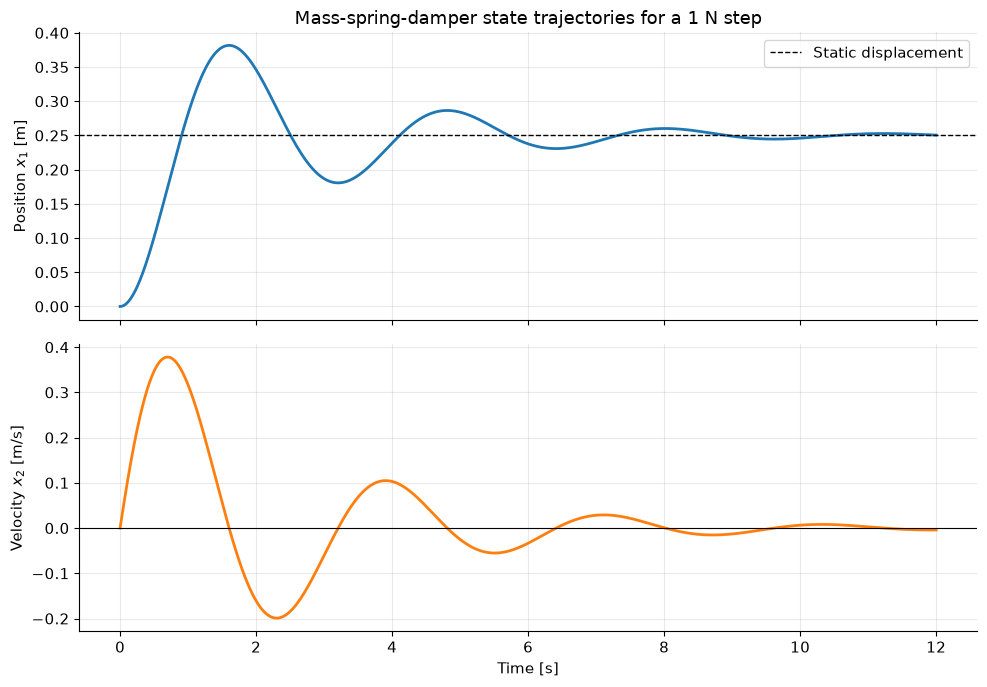

In [19]:
mass, damping, stiffness = 1.0, 0.8, 4.0
A = np.array([[0.0, 1.0], [-stiffness / mass, -damping / mass]])
B = np.array([[0.0], [1.0 / mass]])
C = np.array([[1.0, 0.0]])
D = np.array([[0.0]])
state_space_plant = ct.ss(A, B, C, D)
transfer_from_state_space = ct.ss2tf(state_space_plant)

print("A =\n", A)
print("B =\n", B)
print("C =\n", C)
print("Eigenvalues of A:", np.linalg.eigvals(A))
print("Transfer function recovered from state space:", transfer_from_state_space)

state_time = np.linspace(0, 12, 2000)
state_response = ct.forced_response(
    state_space_plant,
    T=state_time,
    U=np.ones_like(state_time),
    X0=np.zeros(2),
    return_states=True,
)
states = np.asarray(state_response.states)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(state_time, states[0], color=COLORS[0])
axes[0].axhline(1 / stiffness, color="black", linestyle="--", linewidth=1,
                label="Static displacement")
axes[0].set_ylabel("Position $x_1$ [m]")
axes[0].set_title("Mass-spring-damper state trajectories for a 1 N step")
axes[0].legend()
axes[1].plot(state_time, states[1], color=COLORS[1])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Velocity $x_2$ [m/s]")

fig.tight_layout()
plt.show()

## 20. Controllability and Observability

For an $n$-state LTI system, the controllability and observability matrices are

$$\mathcal{C}=\begin{bmatrix}B&AB&\cdots&A^{n-1}B\end{bmatrix},$$

$$\mathcal{O}=\begin{bmatrix}C\\CA\\\vdots\\CA^{n-1}\end{bmatrix}.$$

- $(A,B)$ is **controllable** if $\operatorname{rank}(\mathcal{C})=n$: an input can move the state between arbitrary states in finite time in the ideal model.
- $(A,C)$ is **observable** if $\operatorname{rank}(\mathcal{O})=n$: the initial state can be inferred from input-output history.

If a model is controllable, full-state feedback $u=-Kx+r$ can place the eigenvalues of $A-BK$ at selected locations. If it is observable, an observer can place estimator-error eigenvalues through $A-LC$. The separation principle lets state-feedback and observer poles be designed independently for an LTI model.

For stabilization rather than arbitrary placement, weaker properties called **stabilizability** and **detectability** are sufficient: uncontrollable or unobservable modes must already be stable.

Mass-spring-damper controllability matrix:
 [[ 0.   1. ]
 [ 1.  -0.8]]
rank(Ctrb) = 2 of 2
Mass-spring-damper observability matrix:
 [[1. 0.]
 [0. 1.]]
rank(Obsv) = 2 of 2

State-feedback gain K = [[8.  6.2]]
Placed eigenvalues = [-3.+0.j -4.+0.j]

Example with a disconnected second mode:
controllability rank = 1
observability rank   = 1


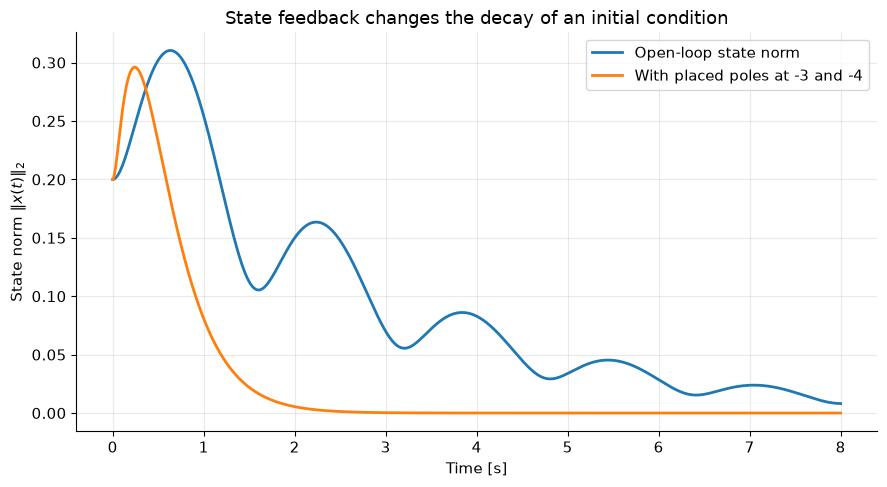

In [20]:
def controllability_matrix(A_matrix, B_matrix):
    state_count = A_matrix.shape[0]
    return np.hstack([
        np.linalg.matrix_power(A_matrix, power) @ B_matrix
        for power in range(state_count)
    ])


def observability_matrix(A_matrix, C_matrix):
    state_count = A_matrix.shape[0]
    return np.vstack([
        C_matrix @ np.linalg.matrix_power(A_matrix, power)
        for power in range(state_count)
    ])


controllability = controllability_matrix(A, B)
observability = observability_matrix(A, C)
print("Mass-spring-damper controllability matrix:\n", controllability)
print("rank(Ctrb) =", np.linalg.matrix_rank(controllability), "of", A.shape[0])
print("Mass-spring-damper observability matrix:\n", observability)
print("rank(Obsv) =", np.linalg.matrix_rank(observability), "of", A.shape[0])

desired_poles = np.array([-3.0, -4.0])
state_feedback_gain = signal.place_poles(A, B, desired_poles).gain_matrix
closed_state_matrix = A - B @ state_feedback_gain
print("\nState-feedback gain K =", state_feedback_gain)
print("Placed eigenvalues =", np.linalg.eigvals(closed_state_matrix))

hidden_A = np.diag([-1.0, -2.0])
hidden_B = np.array([[1.0], [0.0]])
hidden_C = np.array([[1.0, 0.0]])
print("\nExample with a disconnected second mode:")
print("controllability rank =", np.linalg.matrix_rank(controllability_matrix(hidden_A, hidden_B)))
print("observability rank   =", np.linalg.matrix_rank(observability_matrix(hidden_A, hidden_C)))

initial_time = np.linspace(0, 8, 1200)
full_state_output = np.eye(2)
zero_feedthrough = np.zeros((2, 1))
open_state_model = ct.ss(A, B, full_state_output, zero_feedthrough)
closed_state_model = ct.ss(closed_state_matrix, B, full_state_output, zero_feedthrough)
initial_state = np.array([0.2, 0.0])
open_initial = ct.initial_response(open_state_model, T=initial_time, X0=initial_state)
closed_initial = ct.initial_response(closed_state_model, T=initial_time, X0=initial_state)
open_norm = np.linalg.norm(np.asarray(open_initial.outputs), axis=0)
closed_norm = np.linalg.norm(np.asarray(closed_initial.outputs), axis=0)

plt.plot(initial_time, open_norm, label="Open-loop state norm")
plt.plot(initial_time, closed_norm, label="With placed poles at -3 and -4")
plt.title("State feedback changes the decay of an initial condition")
plt.xlabel("Time [s]")
plt.ylabel(r"State norm $\|x(t)\|_2$")
plt.legend()
plt.tight_layout()
plt.show()

## 21. Discrete-Time Control Systems

A digital controller samples signals every $T_s$ seconds. A zero-order hold (ZOH) keeps each commanded value constant until the next sample. The resulting model is

$$x[k+1]=A_dx[k]+B_du[k],\qquad y[k]=C_dx[k]+D_du[k].$$

Continuous poles map approximately/exactly under sampled state evolution as

$$z=e^{sT_s}.$$

Consequently:

- continuous LHP $\rightarrow |z|<1$;
- continuous imaginary axis $\rightarrow |z|=1$;
- continuous RHP $\rightarrow |z|>1$.

A discrete-time rational system is asymptotically stable when all poles lie strictly inside the unit circle. Sampling also introduces phase lag, ZOH effects, quantization, and computational delay. Aliasing occurs when sampled content above half the sample rate folds into lower frequencies, so analog anti-alias filtering is essential.

A common starting guideline is a sample rate 10 to 20 times the desired closed-loop bandwidth in Hz, but fast resonances, noise, delay, hardware limits, and required margins must determine the final rate. Nyquist's two-samples-per-cycle limit is an information boundary, not a good control-design target.

Sample period = 0.200 s; sample rate = 5.0 Hz
Continuous poles:        [-0.4+1.9596j -0.4-1.9596j]
Discrete poles:          [0.8531+0.3526j 0.8531-0.3526j]
exp(s*Ts) prediction:    [0.8531+0.3526j 0.8531-0.3526j]
Discrete-pole magnitudes: [0.9231 0.9231]


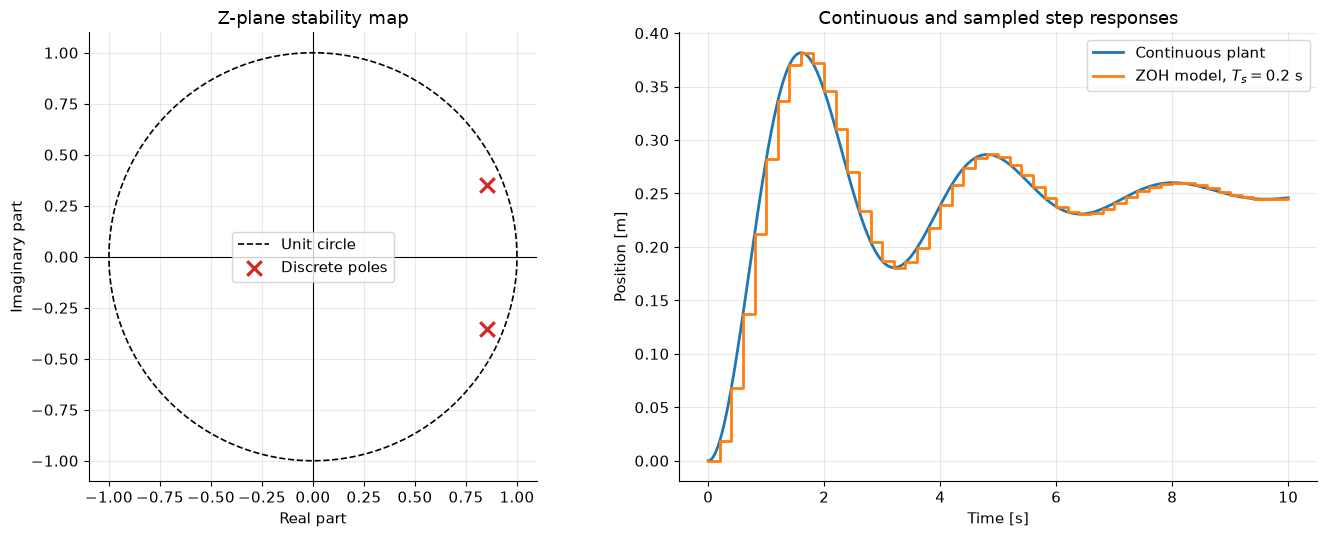

In [21]:
sample_period = 0.2  # s
Ad, Bd, Cd, Dd, returned_period = signal.cont2discrete(
    (A, B, C, D), sample_period, method="zoh"
)
continuous_poles = np.linalg.eigvals(A)
discrete_poles = np.linalg.eigvals(Ad)
mapped_poles = np.exp(continuous_poles * sample_period)

print(f"Sample period = {returned_period:.3f} s; sample rate = {1/returned_period:.1f} Hz")
print("Continuous poles:       ", continuous_poles)
print("Discrete poles:         ", discrete_poles)
print("exp(s*Ts) prediction:   ", mapped_poles)
print("Discrete-pole magnitudes:", np.abs(discrete_poles))

unit_circle_angle = np.linspace(0, 2 * np.pi, 500)
comparison_time = np.linspace(0, 10, 2000)
sample_times = np.arange(0, 10 + sample_period, sample_period)
discrete_plant = ct.ss(Ad, Bd, Cd, Dd, sample_period)
continuous_step = ct.step_response(state_space_plant, T=comparison_time)
discrete_step = ct.step_response(discrete_plant, T=sample_times)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(np.cos(unit_circle_angle), np.sin(unit_circle_angle), "k--",
             linewidth=1.2, label="Unit circle")
axes[0].scatter(discrete_poles.real, discrete_poles.imag, marker="x", s=110,
                linewidths=2.3, color=COLORS[3], label="Discrete poles")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Z-plane stability map")
axes[0].set_xlabel("Real part")
axes[0].set_ylabel("Imaginary part")
axes[0].legend()

axes[1].plot(continuous_step.time, np.asarray(continuous_step.outputs).squeeze(),
             label="Continuous plant")
axes[1].step(discrete_step.time, np.asarray(discrete_step.outputs).squeeze(), where="post",
             color=COLORS[1], label=f"ZOH model, $T_s={sample_period:g}$ s")
axes[1].set_title("Continuous and sampled step responses")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Position [m]")
axes[1].legend()

fig.tight_layout()
plt.show()

## 22. Integrated Control-System Example

Consider a normalized electromechanical actuator model

$$0.15\ddot{y}+0.7\dot{y}+y=u,
\qquad P(s)=\frac{1}{0.15s^2+0.7s+1}.$$

A repeatable design workflow is:

1. **Define requirements:** command range, rise/settling time, overshoot, steady-state error, disturbance rejection, noise, control limits, and safety constraints.
2. **Choose the operating point and model:** derive or identify dynamics; state assumptions and units.
3. **Validate the model:** compare predicted and measured time/frequency responses.
4. **Analyze the baseline:** poles, zeros, DC gain, stability, transient metrics, bandwidth, and margins.
5. **Choose architecture:** feedback, feedforward, cascade, filters, estimators, and references.
6. **Design and tune:** use root locus, loop shaping, pole placement, optimization, or established tuning rules.
7. **Check robustness and implementation:** uncertainty, delay, sampling, noise, saturation, quantization, and control effort.
8. **Verify progressively:** simulation, Monte Carlo/parameter sweeps, software-in-the-loop, hardware-in-the-loop, guarded commissioning, and regression tests.

Here a filtered PID is used for illustration. A real design would tune gains against explicit requirements and uncertain plant data rather than accept one nominal simulation.

Plant poles: [-2.3333+1.1055j -2.3333-1.1055j]
Plant zeros: []
Plant omega_n = 2.582 rad/s; zeta = 0.904
Controlled poles: [-31.7396+0.j      -2.4791+3.9193j  -2.4791-3.9193j  -1.3022+0.j    ]
Loop gain margin = infinite (no -180 deg phase crossover)
Loop phase margin = 59.67 deg at 3.975 rad/s
Baseline unity feedback: final=0.500, peak time=1.120 s, overshoot=7.35%, settling=1.645 s
Filtered PID           : final=1.000, peak time=0.740 s, overshoot=7.84%, settling=1.849 s


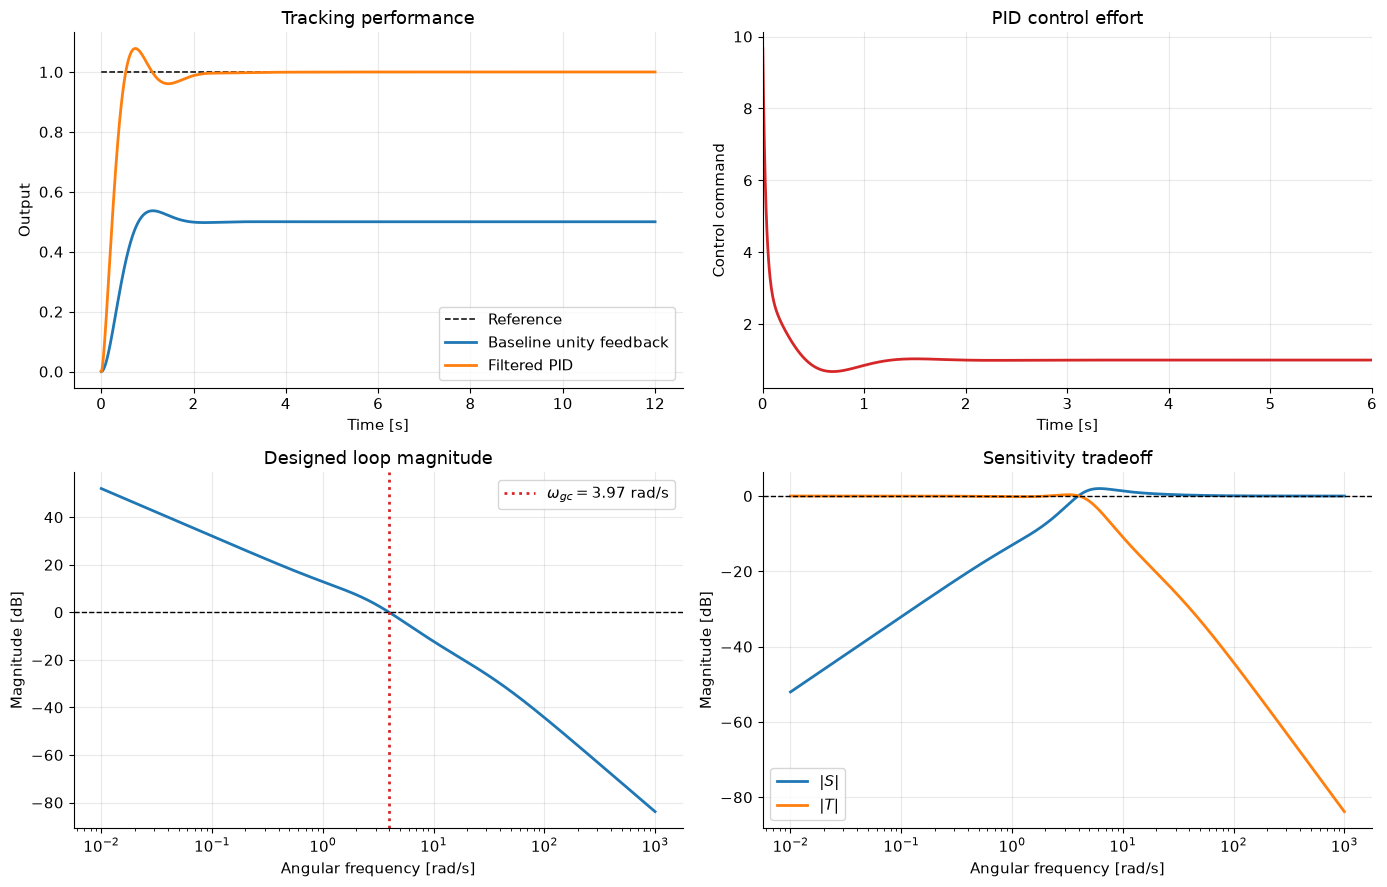

In [23]:
integrated_plant = 1 / (0.15 * s_tf**2 + 0.7 * s_tf + 1)
integrated_controller = 3.0 + 4.0 / s_tf + 0.2 * s_tf / (0.03 * s_tf + 1)
integrated_loop = integrated_controller * integrated_plant
baseline_closed = ct.feedback(integrated_plant, 1)
controlled_closed = ct.feedback(integrated_loop, 1)
integrated_effort = ct.feedback(integrated_controller, integrated_plant)
integrated_sensitivity = ct.feedback(1, integrated_loop)

plant_poles = ct.poles(integrated_plant)
plant_omega_n = np.sqrt(1 / 0.15)
plant_zeta = 0.7 / (2 * np.sqrt(0.15))
gain_margin_i, phase_margin_i, phase_cross_i, gain_cross_i = ct.margin(integrated_loop)
print("Plant poles:", plant_poles)
print("Plant zeros:", ct.zeros(integrated_plant))
print(f"Plant omega_n = {plant_omega_n:.3f} rad/s; zeta = {plant_zeta:.3f}")
print("Controlled poles:", ct.poles(controlled_closed))
if np.isfinite(gain_margin_i):
    print(f"Loop gain margin = {20*np.log10(gain_margin_i):.2f} dB at {phase_cross_i:.3f} rad/s")
else:
    print("Loop gain margin = infinite (no -180 deg phase crossover)")
print(f"Loop phase margin = {phase_margin_i:.2f} deg at {gain_cross_i:.3f} rad/s")

integrated_time = np.linspace(0, 12, 3000)
baseline_step = ct.step_response(baseline_closed, T=integrated_time)
controlled_step = ct.step_response(controlled_closed, T=integrated_time)
effort_step = ct.step_response(integrated_effort, T=integrated_time)
baseline_output = np.asarray(baseline_step.outputs).squeeze()
controlled_output = np.asarray(controlled_step.outputs).squeeze()
control_effort = np.asarray(effort_step.outputs).squeeze()

for name, system, output in [
    ("Baseline unity feedback", baseline_closed, baseline_output),
    ("Filtered PID", controlled_closed, controlled_output),
]:
    final_value = float(ct.dcgain(system))
    _, peak_time, overshoot, settling = measured_step_metrics(
        integrated_time, output, final_value=final_value
    )
    print(
        f"{name:23s}: final={final_value:.3f}, peak time={peak_time:.3f} s, "
        f"overshoot={overshoot:.2f}%, settling={settling:.3f} s"
    )

integrated_omega = np.logspace(-2, 3, 2500)
integrated_loop_response = np.array([
    ct.evalfr(integrated_loop, 1j * value) for value in integrated_omega
])
integrated_s_response = np.array([
    ct.evalfr(integrated_sensitivity, 1j * value) for value in integrated_omega
])
integrated_t_response = np.array([
    ct.evalfr(controlled_closed, 1j * value) for value in integrated_omega
])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(integrated_time, np.ones_like(integrated_time), "k--",
                 linewidth=1.1, label="Reference")
axes[0, 0].plot(integrated_time, baseline_output, label="Baseline unity feedback")
axes[0, 0].plot(integrated_time, controlled_output, label="Filtered PID")
axes[0, 0].set_title("Tracking performance")
axes[0, 0].set_xlabel("Time [s]")
axes[0, 0].set_ylabel("Output")
axes[0, 0].legend()

axes[0, 1].plot(integrated_time, control_effort, color=COLORS[3])
axes[0, 1].set_xlim(0, 6)
axes[0, 1].set_title("PID control effort")
axes[0, 1].set_xlabel("Time [s]")
axes[0, 1].set_ylabel("Control command")

axes[1, 0].semilogx(integrated_omega,
                     20 * np.log10(np.abs(integrated_loop_response)), color=COLORS[0])
axes[1, 0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1, 0].axvline(gain_cross_i, color=COLORS[3], linestyle=":",
                   label=fr"$\omega_{{gc}}={gain_cross_i:.2f}$ rad/s")
axes[1, 0].set_title("Designed loop magnitude")
axes[1, 0].set_xlabel("Angular frequency [rad/s]")
axes[1, 0].set_ylabel("Magnitude [dB]")
axes[1, 0].legend()

axes[1, 1].semilogx(integrated_omega,
                     20 * np.log10(np.abs(integrated_s_response)), label=r"$|S|$")
axes[1, 1].semilogx(integrated_omega,
                     20 * np.log10(np.abs(integrated_t_response)), label=r"$|T|$")
axes[1, 1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("Sensitivity tradeoff")
axes[1, 1].set_xlabel("Angular frequency [rad/s]")
axes[1, 1].set_ylabel("Magnitude [dB]")
axes[1, 1].legend()

fig.tight_layout()
plt.show()

## 23. Practical Realities, Compensators, and Architectures

Control design is never only pole arithmetic. The implemented loop includes sensors, estimators, computation, communication, actuators, safety logic, and a plant whose parameters change.

### Linearization and operating points

A nonlinear model $\dot{x}=f(x,u)$ can be linearized near equilibrium $(x_0,u_0)$:

$$\delta\dot{x}=A\delta x+B\delta u,
\qquad A=\left.\frac{\partial f}{\partial x}\right|_{x_0,u_0},
\quad B=\left.\frac{\partial f}{\partial u}\right|_{x_0,u_0}.$$

The resulting LTI model is local. Large excursions may require gain scheduling, nonlinear control, or a different model.

### Common nonidealities

| Reality | Typical consequence | Common response |
|---|---|---|
| Saturation and rate limits | Windup, slow recovery, limit cycles | Anti-windup, command shaping, constraint-aware design |
| Deadband, backlash, friction, hysteresis | Bias, stick-slip, limit cycles | Compensation, dither, better mechanics, nonlinear model |
| Sensor noise and quantization | Noisy control effort, reduced resolution | Filtering, estimation, sensible bandwidth |
| Transport/computation delay | Extra phase lag, reduced margin | Lower bandwidth, prediction, faster implementation |
| Flexible/high-frequency modes | Spillover or instability | Notch/low-pass filters, model extension, bandwidth separation |
| Parameter/load variation | Shifted poles and margins | Robustness analysis, gain scheduling, adaptive methods |
| MIMO coupling | One loop disrupts another | Pairing analysis, decoupling, multivariable control |

### Lead, lag, and common architectures

A **lead compensator** adds positive phase near crossover and can improve speed/margin:

$$C_{lead}(s)=K\frac{\tau s+1}{\alpha\tau s+1},\qquad 0<\alpha<1.$$

A **lag compensator** raises low-frequency gain relative to high-frequency gain, improving steady error while usually adding some phase lag:

$$C_{lag}(s)=K\frac{\tau s+1}{\beta\tau s+1},\qquad \beta>1.$$

Other foundational structures include feedforward (cancel predictable disturbances or shape commands), cascade control (a fast inner loop inside a slower outer loop), gain scheduling, notch filters, and state observers. Feedforward depends on model accuracy and does not replace stabilizing feedback. A **servo** emphasizes reference tracking; a **regulator** emphasizes holding an operating point against disturbances.

Effect of transport delay, represented by a third-order Pade approximation
delay [s] | phase margin [deg] | rightmost closed-loop pole | result
----------+--------------------+----------------------------+--------
     0.00 |              60.42 |                    -0.8814 | stable
     0.20 |              50.03 |                    -0.6391 | stable
     0.50 |              34.44 |                    -0.3276 | stable
     1.20 |              -1.94 |                     0.0095 | unstable


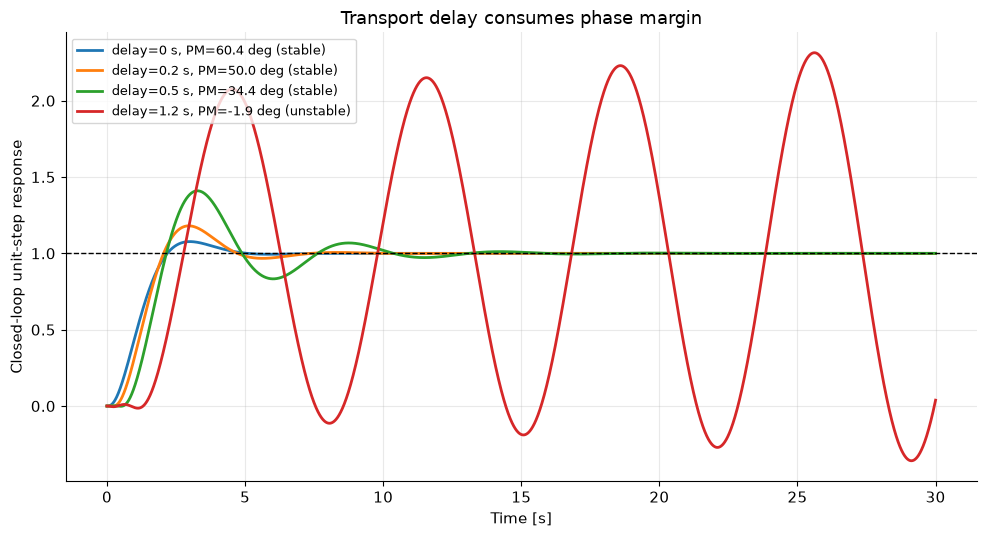

In [26]:
delay_values = [0.0, 0.2, 0.5, 1.2]
delay_time = np.linspace(0, 30, 4000)

print("Effect of transport delay, represented by a third-order Pade approximation")
print("delay [s] | phase margin [deg] | rightmost closed-loop pole | result")
print("----------+--------------------+----------------------------+--------")
plt.figure(figsize=(10, 5.5))
for index, delay in enumerate(delay_values):
    if delay == 0:
        delay_model = ct.tf([1.0], [1.0])
    else:
        delay_numerator, delay_denominator = ct.pade(delay, 3)
        delay_model = ct.tf(delay_numerator, delay_denominator)
    delayed_loop = frequency_loop * delay_model
    delayed_closed_loop = ct.feedback(delayed_loop, 1)
    _, delayed_phase_margin, _, _ = ct.margin(delayed_loop)
    rightmost_pole = np.max(ct.poles(delayed_closed_loop).real)
    result = "stable" if rightmost_pole < 0 else "unstable"
    print(f"{delay:9.2f} | {delayed_phase_margin:18.2f} | {rightmost_pole:26.4f} | {result}")
    response_time, response = ct.step_response(delayed_closed_loop, T=delay_time)
    plt.plot(response_time, response, color=COLORS[index],
             label=f"delay={delay:g} s, PM={delayed_phase_margin:.1f} deg ({result})")

plt.axhline(1, color="black", linestyle="--", linewidth=1)
plt.title("Transport delay consumes phase margin")
plt.xlabel("Time [s]")
plt.ylabel("Closed-loop unit-step response")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 24. Compact Control-Systems Cheat Sheet

| Topic | Core result |
|---|---|
| First-order system | $G=K/(\tau s+1)$, pole $=-1/\tau$, $y(\tau)=0.632K$, $t_s\approx4\tau$ |
| Standard second order | $G=\omega_n^2/(s^2+2\zeta\omega_ns+\omega_n^2)$ |
| General second order | $\omega_n=\sqrt{a_0/a_2}$, $\zeta=a_1/(2\sqrt{a_0a_2})$ |
| Underdamped poles | $-\zeta\omega_n\pm j\omega_n\sqrt{1-\zeta^2}$ |
| 2% settling estimate | $t_s\approx4/(\zeta\omega_n)=4/|\operatorname{Re}p|$ for a dominant pair |
| Percent overshoot | $100e^{-\pi\zeta/\sqrt{1-\zeta^2}}$ for canonical $0<\zeta<1$ |
| Series RLC, capacitor output | $\omega_n=1/\sqrt{LC}$, $\zeta=(R/2)\sqrt{C/L}$, $R_{crit}=2\sqrt{L/C}$ |
| Continuous stability | Strict LHP poles for asymptotic/BIBO stability of a minimal rational model |
| Discrete stability | All poles strictly inside $|z|=1$ |
| Negative feedback | $T=L/(1+L)$, $S=1/(1+L)$, $S+T=1$ |
| Characteristic equation | $1+L(s)=0$ |
| System type | Number of uncanceled loop poles at the origin |
| State-space poles | Eigenvalues of $A$; transfer poles for a minimal realization |
| Controllability / observability | $\operatorname{rank}\mathcal{C}=n$ / $\operatorname{rank}\mathcal{O}=n$ |
| Pole sampling map | $z=e^{sT_s}$ |

### Questions to ask on every design

1. What input, output, operating point, sign convention, and units are being used?
2. Which dynamics and nonlinearities are included or omitted?
3. Are all internal modes stable, controllable, and observable where required?
4. What are the tracking, disturbance, noise, transient, and robustness requirements?
5. What control magnitude/rate, sensor, sampling, delay, and safety limits apply?
6. Do nominal, worst-case, and implementation-level tests all pass?

### Common mistakes

- Applying second-order formulas to a high-order response without checking dominant poles and zeros.
- Calling imaginary-axis poles BIBO stable or ignoring repeated boundary poles.
- Assuming a farther-left pole always guarantees a faster complete response.
- Treating an exact pole-zero cancellation as physically reliable.
- Using the final-value theorem before verifying closed-loop stability.
- Tuning only the output while ignoring control effort, saturation, and noise.
- Implementing an ideal derivative or forgetting anti-windup.
- Choosing a sample rate from Nyquist alone instead of bandwidth, delay, and fast modes.
- Reporting good nominal margins while ignoring parameter uncertainty and transport delay.

## Exercises

### 1. Extract second-order parameters

For $G(s)=10/(2s^2+8s+50)$, find $\omega_n$, $\zeta$, and the poles.

<details>
<summary>Answer check</summary>

Normalize the denominator: $s^2+4s+25$. Therefore $\omega_n=5$ rad/s, $\zeta=4/(2\cdot5)=0.4$, and $p=-2\pm j\sqrt{21}\approx-2\pm j4.583$ rad/s.

</details>

### 2. Design RLC damping

A series RLC circuit has $L=20$ mH and $C=50$ uF. Find $\omega_n$, the resistance for $\zeta=0.7$, and the critical resistance.

<details>
<summary>Answer check</summary>

$LC=10^{-6}$, so $\omega_n=1000$ rad/s. Since $\sqrt{L/C}=20$, $R=2(0.7)(20)=28$ ohm and $R_{crit}=2(20)=40$ ohm.

</details>

### 3. Read performance from poles

A dominant pair is $-3\pm j4$. Estimate $\omega_n$, $\zeta$, 2% settling time, and canonical percent overshoot.

<details>
<summary>Answer check</summary>

$\omega_n=5$ rad/s, $\zeta=3/5=0.6$, $t_s\approx4/3=1.33$ s, and $M_p\approx100e^{-\pi(0.6)/0.8}=9.5\%$.

</details>

### 4. Interpret an RHP zero

Two stable systems have identical poles and DC gain; one has a zero at $-2$, the other at $+2$. Which is nonminimum phase, and what time-domain clue may reveal it?

<details>
<summary>Answer check</summary>

The $+2$ zero is in the RHP and is nonminimum phase. Its step response may initially move opposite the final direction. It also contributes more phase lag and limits achievable bandwidth.

</details>

### 5. Determine system type

For unity feedback with $L(s)=20(s+3)/[s(s+1)(s+5)]$, state the system type and the expected unit-step and unit-ramp steady-state errors.

<details>
<summary>Answer check</summary>

There is one uncanceled pole at the origin, so it is type 1. If the closed loop is stable, step error is zero. $K_v=\lim_{s\to0}sL(s)=20(3)/(1\cdot5)=12$, so unit-ramp error is $1/12$.

</details>

### 6. Map a pole into the z-plane

Map $s=-2+j6$ with $T_s=0.05$ s. Is the sampled pole stable?

<details>
<summary>Answer check</summary>

$z=e^{(-2+j6)0.05}=e^{-0.1}e^{j0.3}$. Its magnitude is $e^{-0.1}\approx0.9048<1$, so it is inside the unit circle and stable.

</details>

## Where to Go Next

After these foundations, natural next topics are LQR/LQG and Kalman filtering, robust control ($H_\infty$, structured uncertainty), model predictive control, system identification, adaptive control, nonlinear control, and multivariable loop analysis. Each extends the same central discipline: model the dynamics, state assumptions, shape closed-loop behavior, and verify robustness against the real implementation.